# 🚀 Transformer Compiler C→ARM — Entraînement & Export FPGA (ZedBoard)

Pipeline organisé en une seule passe :
**Dataset → Tokenizer → Modèle → Entraînement → Évaluation → Quantization Q8.8 → Export FPGA/HLS → Sauvegarde**


## 1. Installation des dépendances et vérification GPU

In [1]:
# ============================================================
# 📦 INSTALLATION
# ============================================================
!pip install -q torch torchvision
!pip install -q pandas scikit-learn matplotlib seaborn tqdm

import torch
print(f"🖥️ GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Modèle GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Mémoire: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ GPU non activé — Runtime → Change runtime type → GPU")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


🖥️ GPU disponible: True
   Modèle GPU: Tesla T4
   Mémoire: 15.6 GB


### 2. Constantes globales

In [2]:

VOCAB_SIZE  = 100
EMBED_DIM   = 16   # = D_MODEL côté HLS
SEQ_LEN     = 16   # doit rester synchro avec le buffer HLS côté FPGA
NUM_HEADS   = 2
D_HEAD      = EMBED_DIM // NUM_HEADS
FF_DIM      = 32   # = D_FF côté HLS
NUM_CLASSES = 4

print(f"✅ Constantes: VOCAB={VOCAB_SIZE} EMBED_DIM={EMBED_DIM} SEQ_LEN={SEQ_LEN} "
      f"NUM_HEADS={NUM_HEADS} D_HEAD={D_HEAD} FF_DIM={FF_DIM}")

✅ Constantes: VOCAB=100 EMBED_DIM=16 SEQ_LEN=16 NUM_HEADS=2 D_HEAD=8 FF_DIM=32


## 3. Génération du dataset synthétique

10 000 exemples de code C (2 500 par classe) répartis en 4 classes de structures de contrôle :
`IF`, `WHILE`, `FOR`, `SWITCH`.

In [3]:
# ============================================================
# 🗂️ GÉNÉRATION DU DATASET
# ============================================================
import random
import pandas as pd

templates = {
    'IF_STATEMENT': [
        "if ({var} > {num}) {{ {var2} = {num2}; }}",
        "if ({var} < {num}) {{ return {num2}; }}",
        "if ({var} == {num}) {{ {var2} += {num2}; }}",
        "if ({var} != {num}) {{ {var2} = {var} + {num2}; }}",
        "if ({var} >= {num}) {{ break; }}",
        "if ({var} <= {num}) {{ {var2}--; }}",
        "if ({var} > {num} && {var2} < {num2}) {{ return 0; }}",
        "if ({var} == {num} || {var2} != {num2}) {{ {var} = 0; }}",
        "if (!{var}) {{ {var2} = {num}; }}",
        "if ({var} > {num}) {{ {var2} = {var} * {num2}; }}",
        "if ({var} > {num}) {{ {var2} = {num2}; }} else {{ {var2} = 0; }}",
        "if ({var} == {num}) {{ return {num2}; }} else {{ return -1; }}",
        "if ({var} > {num}) {{ if ({var2} < {num2}) {{ return 1; }} }}",
        "if ({var}) {{ {var} = {num}; }}",
        "{var2} = ({var} > {num}) ? {num2} : 0;",
        # --- AJOUT : préfixe de déclaration (token 'int', absent avant) ---
        "int {var} = {num}; if ({var} > {num2}) {{ {var2} = {num2}; }}",
        "int {var} = 0; if ({var} == {num}) {{ {var2}++; }}",
        "int {var2} = {num}; if ({var} != {var2}) {{ return {num2}; }}",
        # --- AJOUT : imbrication croisée (if contenant for/while/switch) ---
        "if ({var} > {num}) {{ for ({var2} = 0; {var2} < {num2}; {var2}++) {{}} }}",
        "if ({var} > {num}) {{ while ({var2} > 0) {{ {var2}--; }} }}",
        "if ({var} == {num}) {{ switch ({var2}) {{ case {num2}: break; }} }}",
    ],
    'WHILE_LOOP': [
        "while ({var} < {num}) {{ {var}++; }}",
        "while ({var} > {num}) {{ {var}--; }}",
        "while ({var} != {num}) {{ {var2} = {var} * {num2}; {var}++; }}",
        "while ({var} <= {num}) {{ {var} += {num2}; }}",
        "while ({var} >= {num}) {{ {var} -= {num2}; }}",
        "while ({var} < {num} && {var2} > 0) {{ {var}++; }}",
        "while ({var} != {num} || {var2} == {num2}) {{ {var}++; }}",
        "while ({var} < {num}) {{ {var2} += {var}; {var}++; }}",
        "while ({var} > 0) {{ {var2} *= 2; {var}--; }}",
        "while ({var} < {num}) {{ if ({var2} > {num2}) break; {var}++; }}",
        "while (1) {{ {var}++; if ({var} > {num}) break; }}",
        "while (!{var}) {{ {var} = {num}; }}",
        "while ({var}) {{ {var}--; }}",
        "while ({var} < {num}) {{ while ({var2} > 0) {{ {var2}--; }} {var}++; }}",
        # --- AJOUT : préfixe de déclaration ---
        "int {var} = 0; while ({var} < {num}) {{ {var}++; }}",
        "int {var} = {num}; while ({var} > 0) {{ {var}--; }}",
        "int {var2} = {num2}; while ({var} != {var2}) {{ {var}++; }}",
        # --- AJOUT : imbrication croisée (while contenant for/switch) ---
        "while ({var} < {num}) {{ for ({var2} = 0; {var2} < {num2}; {var2}++) {{}} }}",
        "while ({var} > 0) {{ switch ({var2}) {{ case {num}: break; }} {var}--; }}",
        "while ({var} < {num}) {{ switch ({var2}) {{ case {num2}: {var}++; break; }} }}",
    ],
    'FOR_LOOP': [
        "for ({var} = 0; {var} < {num}; {var}++) {{ {var2} += {var}; }}",
        "for ({var} = {num}; {var} > 0; {var}--) {{ {var2}--; }}",
        "for ({var} = 0; {var} <= {num}; {var}++) {{}}",
        "for ({var} = {num2}; {var} < {num}; {var} += {num2}) {{ sum += {var}; }}",
        "for ({var} = 0; {var} < {num}; {var} += 2) {{ {var2} *= {var}; }}",
        "for ({var} = {num}; {var} >= 0; {var} -= {num2}) {{ {var2}++; }}",
        "for ({var} = 0; {var} < {num}; {var}++) {{ result *= {var}; }}",
        "for ({var} = 1; {var} <= {num}; {var}++) {{ {var2} = {var2} * {var}; }}",
        "for ({var} = 0; {var} < {num} && {var2} > 0; {var}++) {{ {var2}--; }}",
        "for ({var} = 0; {var} < {num}; {var}++) {{ for ({var2} = 0; {var2} < {num2}; {var2}++) {{}} }}",
        "for (;{var} < {num};) {{ {var}++; }}",
        "for ({var} = 0;;{var}++) {{ if ({var} >= {num}) break; }}",
        "for ({var} = 0; {var} < {num}; {var}++) {{ if ({var} == {num2}) break; }}",
        "for ({var} = 0; {var} < {num}; {var}++) {{ if ({var} % 2 == 0) continue; {var2}++; }}",
        # --- AJOUT : préfixe de déclaration (avant la boucle for elle-même) ---
        "int {var2} = 0; for ({var} = 0; {var} < {num}; {var}++) {{ {var2} += {var}; }}",
        "int {var2} = {num}; for ({var} = 0; {var} < {num2}; {var}++) {{ {var2}--; }}",
        "int {var} = {num}; for ({var2} = 0; {var2} < {var}; {var2}++) {{}}",
        # --- AJOUT : imbrication croisée (for contenant while/switch/if) ---
        "for ({var} = 0; {var} < {num}; {var}++) {{ while ({var2} > 0) {{ {var2}--; }} }}",
        "for ({var} = 0; {var} < {num}; {var}++) {{ switch ({var2}) {{ case {num2}: break; }} }}",
        "for ({var} = 0; {var} < {num}; {var}++) {{ if ({var2} == {num2}) {{ break; }} }}",
    ],
    'SWITCH_CASE': [
        "switch ({var}) {{ case {num}: break; }}",
        "switch ({var}) {{ case {num}: {var2} = {num2}; break; }}",
        "switch ({var}) {{ case {num}: return {num2}; }}",
        "switch ({var}) {{ case {num}: {var2}++; break; }}",
        "switch ({var}) {{ case {num}: break; case {num2}: break; }}",
        "switch ({var}) {{ case {num}: {var2} = 0; break; case {num2}: {var2} = 1; break; }}",
        "switch ({var}) {{ case {num}: case {num2}: {var2} = {num}; break; }}",
        "switch ({var}) {{ case {num}: break; default: {var2} = -1; }}",
        "switch ({var}) {{ default: return 0; }}",
        "switch ({var}) {{ case {num}: {var2}++; case {num2}: {var2}--; break; }}",
        "switch ({var}) {{ case {num}: return {num2}; default: return -1; }}",
        "switch ({var}) {{ case {num}: {var2} = {var} + {num2}; break; }}",
        "switch ({var}) {{ case {num}: {var2} *= 2; break; case {num2}: {var2} /= 2; break; }}",
        # --- AJOUT : préfixe de déclaration ---
        "int {var} = {num}; switch ({var}) {{ case {num2}: break; }}",
        "int {var2} = {num2}; switch ({var}) {{ case {num}: {var2} = 0; break; }}",
        "int {var} = {num2}; switch ({var}) {{ default: break; }}",
        # --- AJOUT : imbrication croisée (switch contenant for/while/if) ---
        "switch ({var}) {{ case {num}: for ({var2} = 0; {var2} < {num2}; {var2}++) {{}} break; }}",
        "switch ({var}) {{ case {num}: while ({var2} > 0) {{ {var2}--; }} break; }}",
        "switch ({var}) {{ case {num}: if ({var2} > {num2}) {{ break; }} }}",
    ]
}

variables = ['i', 'j', 'k', 'x', 'y', 'z', 'count', 'index', 'value', 'temp', 'n', 'm']
variables2 = ['sum', 'result', 'output', 'data', 'total', 'flag', 'status', 'res', 'val', 'acc']

def generate_code(pattern, count=2500):
    examples = []
    for _ in range(count):
        template = random.choice(templates[pattern])
        num1 = random.choice([
            random.randint(0, 10),
            random.randint(10, 100),
            random.randint(100, 1000)
        ])
        num2 = random.randint(0, 100)
        code_str = template.format(
            var=random.choice(variables),
            var2=random.choice(variables2),
            num=num1,
            num2=num2
        )
        examples.append({'code': code_str, 'label': pattern})
    return examples

print("🗂️ Génération du dataset (10 000 exemples)...")
dataset = []
for pattern in templates.keys():
    dataset.extend(generate_code(pattern, count=2500))

random.shuffle(dataset)
df = pd.DataFrame(dataset)

print(f"✅ Dataset généré: {len(df):,} exemples")
print(df['label'].value_counts())
print(f"Codes uniques: {df['code'].nunique():,} / {len(df):,} ({100*df['code'].nunique()/len(df):.1f}%)")

🗂️ Génération du dataset (10 000 exemples)...
✅ Dataset généré: 10,000 exemples
label
WHILE_LOOP      2500
SWITCH_CASE     2500
FOR_LOOP        2500
IF_STATEMENT    2500
Name: count, dtype: int64
Codes uniques: 9,596 / 10,000 (96.0%)


## 4. Tokenizer

In [4]:
print("🔢 Création du tokenizer...\n")

import re
import numpy as np

TOKEN_MAP = {
    'if': 1, 'else': 2, 'while': 3, 'for': 4, 'switch': 5,
    'case': 6, 'return': 7, 'break': 8, 'int': 9, 'void': 10,
    '>': 20, '<': 21, '==': 22, '!=': 23, '>=': 24, '<=': 25,
    '=': 40, '+': 41, '-': 42, '*': 43, '/': 44,
    '++': 45, '--': 46, '+=': 47, '-=': 48, '*=': 49,
    '(': 50, ')': 51, '{': 52, '}': 53, ';': 54, ':': 55,
    'VAR': 60, 'NUM': 61,
    'UNKNOWN': 0
}

LABEL_MAP = {'IF_STATEMENT': 0, 'WHILE_LOOP': 1, 'FOR_LOOP': 2, 'SWITCH_CASE': 3}
CLASS_NAMES = ['IF', 'WHILE', 'FOR', 'SWITCH']

TOKEN_PATTERN = r'(==|!=|>=|<=|\+\+|--|\+=|-=|\*=|[+\-*/=<>(){};:]|\w+)'

def tokenize(code_str, max_len=SEQ_LEN):
    code_str = re.sub(r'\s+', ' ', code_str.strip())
    words = re.findall(TOKEN_PATTERN, code_str)
    tokens = []
    for word in words:
        if word in TOKEN_MAP:
            tokens.append(TOKEN_MAP[word])
        elif word.isdigit():
            tokens.append(TOKEN_MAP['NUM'])
        elif word.isalpha():
            tokens.append(TOKEN_MAP['VAR'])
        else:
            tokens.append(TOKEN_MAP['UNKNOWN'])
    if len(tokens) < max_len:
        tokens += [0] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens

df['tokens'] = df['code'].apply(tokenize)
df['label_id'] = df['label'].apply(lambda x: LABEL_MAP[x])

print("✅ Tokenization terminée")
print(f"Exemple: {df.iloc[0]['code']}")
print(f"Tokens : {df.iloc[0]['tokens']}")
print(f"Label  : {df.iloc[0]['label']} (id={df.iloc[0]['label_id']})")

🔢 Création du tokenizer...

✅ Tokenization terminée
Exemple: while (x < 230) { x++; }
Tokens : [3, 50, 60, 21, 61, 51, 52, 60, 45, 54, 53, 0, 0, 0, 0, 0]
Label  : WHILE_LOOP (id=1)


## 5. Dataset PyTorch & DataLoaders

In [5]:
# ============================================================
# 🏗️ DATASET PYTORCH — split 70/15/15
# ============================================================
print("\n🏗️ Création du PyTorch Dataset...\n")

from torch.utils.data import Dataset, DataLoader, random_split

class CodeDataset(Dataset):
    def __init__(self, dataframe):
        self.tokens = torch.tensor(np.stack(dataframe['tokens'].values), dtype=torch.long)
        self.labels = torch.tensor(dataframe['label_id'].values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tokens[idx], self.labels[idx]

full_dataset = CodeDataset(df)

total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"📦 Batch size: {BATCH_SIZE}")


🏗️ Création du PyTorch Dataset...

✅ Train: 7000 | Val: 1500 | Test: 1500
📦 Batch size: 64


## 6. Définition du modèle Transformer

In [6]:
# AJOUT : Positional Encoding sinusoïdal — l'attention seule est invariante
# par permutation (elle ne "voit" pas l'ordre des tokens), donc sans PE le
# modèle ne peut distinguer un token qui apparaît en position 2 vs position 8.
# Choix : encodage FIXE (sin/cos), pas appris.
#   - Aucun paramètre supplémentaire à entraîner
#   - Table déterministe, calculable une fois en Python et exportée telle
#     quelle (positional_encoding.h) : côté FPGA, c'est une simple ADDITION,
#     jamais de sin()/cos() à calculer en HLS — ce qui aurait été coûteux
#     dans un pipeline déjà à II=1 avec un budget DSP serré.
print("\n🧠 Création du modèle Transformer (avec Positional Encoding)...\n")

import math
import torch.nn as nn

class TransformerCompiler(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
                 ff_dim=FF_DIM, num_classes=NUM_CLASSES, seq_len=SEQ_LEN):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        pe = torch.zeros(seq_len, embed_dim)
        position = torch.arange(0, seq_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2, dtype=torch.float32) *
                              (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pos_encoding', pe)  # [seq_len, embed_dim] — non entraîné

        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, tokens):
        seq_len = tokens.size(1)
        x = self.embedding(tokens) + self.pos_encoding[:seq_len, :]
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        x = x.mean(dim=1)
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerCompiler().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modèle créé sur {device}")
print(f"   Paramètres entraînables: {total_params:,}  ({total_params * 4 / 1e6:.2f} MB en FP32)")
print(f"   Positional encoding: {model.pos_encoding.numel()} valeurs fixes (non comptées ci-dessus, non entraînées)")
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"   {name:12s}: {n:6,} params")



🧠 Création du modèle Transformer (avec Positional Encoding)...

✅ Modèle créé sur cuda
   Paramètres entraînables: 3,892  (0.02 MB en FP32)
   Positional encoding: 256 valeurs fixes (non comptées ci-dessus, non entraînées)
   embedding   :  1,600 params
   attention   :  1,088 params
   norm1       :     32 params
   ffn         :  1,072 params
   norm2       :     32 params
   classifier  :     68 params


## 7. Entraînement

In [7]:
print("🎯 Démarrage de l'entraînement...\n")

import torch.optim as optim
from tqdm import tqdm

NUM_EPOCHS = 300
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)

    for tokens, labels in pbar:
        tokens, labels = tokens.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(tokens)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{100.0*train_correct/train_total:.2f}%"})

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100.0 * train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for tokens, labels in val_loader:
            tokens, labels = tokens.to(device), labels.to(device)
            logits = model(tokens)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100.0 * val_correct / val_total

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train loss={avg_train_loss:.4f} acc={train_acc:.2f}% | "
              f"Val loss={avg_val_loss:.4f} acc={val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

print(f"\n🎉 Entraînement terminé — meilleure val accuracy: {best_val_acc:.2f}%")

🎯 Démarrage de l'entraînement...



Epoch [1/300] Train loss=1.0973 acc=61.80% | Val loss=0.8213 acc=79.20%


Epoch [10/300] Train loss=0.3532 acc=100.00% | Val loss=0.3527 acc=100.00%


Epoch [20/300] Train loss=0.3495 acc=100.00% | Val loss=0.3495 acc=100.00%


Epoch [30/300] Train loss=0.3491 acc=100.00% | Val loss=0.3491 acc=100.00%


...

Epoch [260/300] Train loss=0.3488 acc=100.00% | Val loss=0.3488 acc=100.00%


Epoch [270/300] Train loss=0.3488 acc=100.00% | Val loss=0.3488 acc=100.00%


Epoch [280/300] Train loss=0.3488 acc=100.00% | Val loss=0.3488 acc=100.00%


Epoch [290/300] Train loss=0.3488 acc=100.00% | Val loss=0.3488 acc=100.00%


Epoch [300/300] Train loss=0.3489 acc=100.00% | Val loss=0.3488 acc=100.00%

🎉 Entraînement terminé — meilleure val accuracy: 100.00%


## 8. Visualisation des courbes d'entraînement


📊 Visualisation de l'entraînement...



NameError: name 'history' is not defined

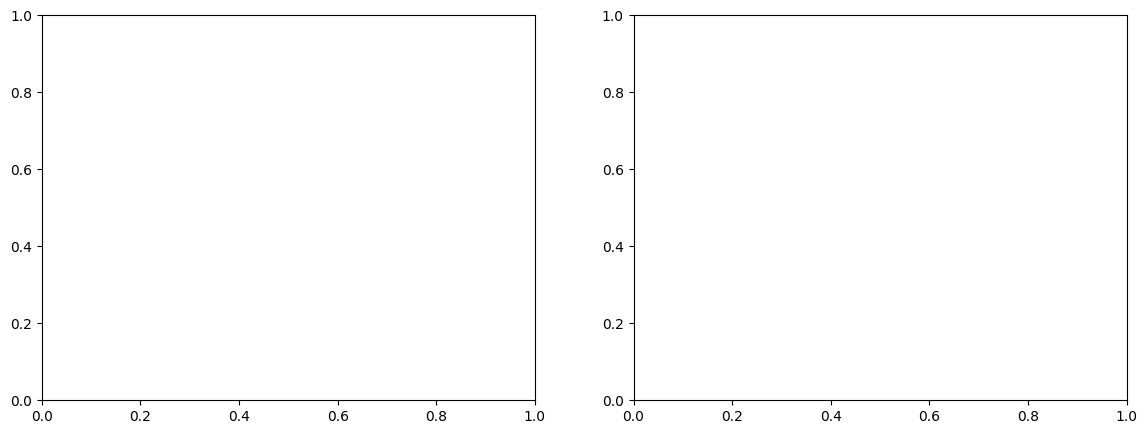

In [10]:
print("\n📊 Visualisation de l'entraînement...\n")

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Accuracy', linewidth=2)
ax2.plot(history['val_acc'], label='Val Accuracy', linewidth=2)
ax2.axhline(y=90, color='g', linestyle='--', alpha=0.5, label='90% threshold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ training_curves.png sauvegardé")

## 9. Évaluation sur le test set


✅ Évaluation sur le test set...

🎯 Test Accuracy: 100.00%

              precision    recall  f1-score   support

          IF     1.0000    1.0000    1.0000       391
       WHILE     1.0000    1.0000    1.0000       351
         FOR     1.0000    1.0000    1.0000       400
      SWITCH     1.0000    1.0000    1.0000       358

    accuracy                         1.0000      1500
   macro avg     1.0000    1.0000    1.0000      1500
weighted avg     1.0000    1.0000    1.0000      1500



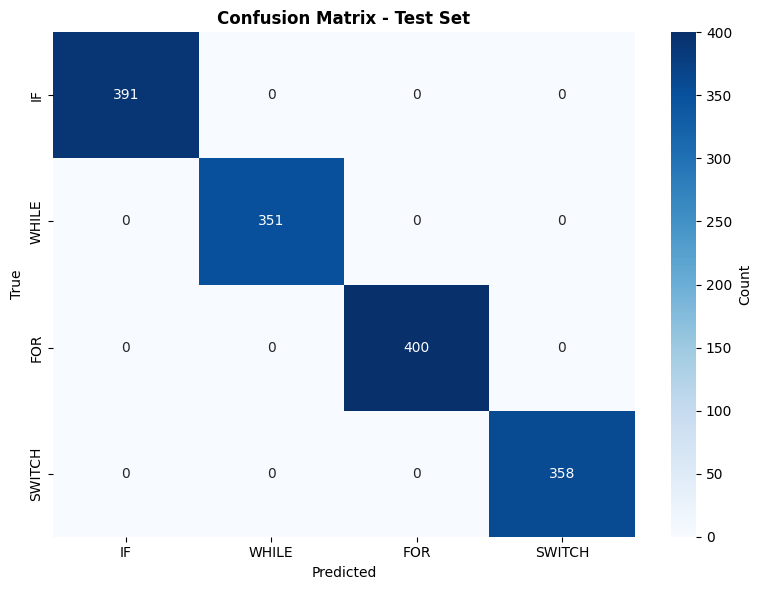

✅ confusion_matrix.png sauvegardé


In [11]:
print("\n✅ Évaluation sur le test set...\n")

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for tokens, labels in test_loader:
        tokens = tokens.to(device)
        logits = model(tokens)
        _, predicted = torch.max(logits, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = 100.0 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"🎯 Test Accuracy: {test_acc:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ confusion_matrix.png sauvegardé")

## 10. Quantisation Q8.8 (poids du modèle PyTorch)

Format fixe 16 bits Q8.8 : `valeur_quantifiée = round(clip(valeur, -128, 127.996) × 256)`.
Utilisé pour sauvegarder une copie quantifiée du `state_dict` complet, et pour un export
binaire brut (optionnel, utile pour un chargement depuis carte SD sur la ZedBoard).

In [20]:
print("\n🔢 Quantization FP32 → Q8.8 (state_dict complet)...\n")

def quantize_to_q8_8(tensor):
    clipped = torch.clamp(tensor, -128.0, 127.996)
    return torch.round(clipped * 256.0).to(torch.int16)

quantized_weights = {}
total_clipped, total_weights = 0, 0

for name, param in model.named_parameters():
    quantized_weights[name] = quantize_to_q8_8(param.data.cpu())
    clipped_count = (param.data.cpu().abs() > 128).sum().item()
    total_clipped += clipped_count
    total_weights += param.numel()
    if clipped_count > 0:
        print(f"⚠️ {name}: {clipped_count}/{param.numel()} valeurs clippées")

overall_pct = 100.0 * total_clipped / total_weights
print(f"\n📊 Clipping global: {total_clipped:,}/{total_weights:,} ({overall_pct:.2f}%)")
print("   ✅ Excellent" if overall_pct < 5 else "   ⚠️ Vérifier (>5% clipping)")

torch.save(quantized_weights, 'model_quantized_q8_8.pth')
print("✅ model_quantized_q8_8.pth sauvegardé")

all_weights = [w.flatten().numpy() for n, w in sorted(quantized_weights.items()) if 'weight' in n]
np.concatenate(all_weights).astype(np.int16).tofile('weights.bin')
print("✅ weights.bin sauvegardé")


🔢 Quantization FP32 → Q8.8 (state_dict complet)...


📊 Clipping global: 0/3,892 (0.00%)
   ✅ Excellent
✅ model_quantized_q8_8.pth sauvegardé
✅ weights.bin sauvegardé


## 11. Export FPGA — poids attention/FFN réorganisés pour HLS multi-head

**Note de correction :** le notebook original contenait deux logiques d'export concurrentes.
Une version exportait les poids d'attention "à plat" (flatten direct de `in_proj_weight`),
ce qui ne correspond **pas** au layout mémoire attendu par le code HLS multi-head
(`Wq[tête][i][j]`, poids transposés `[in_features, out_features]`). Seule la version
réorganisée par tête + transposée est correcte et conservée ici — c'est elle qui avait
été validée et sauvegardée sur Drive en dernier dans le notebook original.

In [21]:
print("\n💾 Export weights_fpga.h...\n")

import os
import numpy as np
import torch.nn as nn
import torch

def quantize_array(arr):
    clipped = np.clip(arr, -128.0, 127.996)
    return np.round(clipped * 256.0).astype(np.int16)

def reorganize_per_head(W_out_in, num_heads=NUM_HEADS, d_head=D_HEAD):
    """[out_features, in_features] -> transposé, découpé par tête, concaténé."""
    W_t = W_out_in.T
    heads = [W_t[:, h*d_head:(h+1)*d_head].flatten() for h in range(num_heads)]
    return np.concatenate(heads)

def write_c_array(f, name, data):
    f.write(f"const int16_t {name}[{len(data)}] = {{\n")
    for i in range(0, len(data), 16):
        chunk = data[i:i+16]
        line = ', '.join([f"{int(w):6d}" for w in chunk])
        f.write(f"    {line}")
        f.write(",\n" if i + 16 < len(data) else "\n")
    f.write("};\n\n")

model.eval()
with torch.no_grad():
    in_proj = model.attention.in_proj_weight.data.cpu().numpy()
    Wq_pt, Wk_pt, Wv_pt = in_proj[0:EMBED_DIM, :], in_proj[EMBED_DIM:2*EMBED_DIM, :], in_proj[2*EMBED_DIM:3*EMBED_DIM, :]

    Wq_hls = reorganize_per_head(Wq_pt)
    Wk_hls = reorganize_per_head(Wk_pt)
    Wv_hls = reorganize_per_head(Wv_pt)

    Wo_hls = model.attention.out_proj.weight.data.cpu().numpy().T.flatten()
    W1_hls = model.ffn[0].weight.data.cpu().numpy().T.flatten()
    W2_hls = model.ffn[2].weight.data.cpu().numpy().T.flatten()

in_proj_q8 = np.concatenate([quantize_array(Wq_hls), quantize_array(Wk_hls), quantize_array(Wv_hls)])
Wo_q8 = quantize_array(Wo_hls)
W1_q8 = quantize_array(W1_hls)
W2_q8 = quantize_array(W2_hls)

with open('weights_fpga.h', 'w') as f:
    f.write("/* Poids Transformer - reorganises pour HLS multi-head */\n")
    f.write("/* Layout: [Tete0][Tete1] pour Wq/Wk/Wv, matrices transposees [in,out] */\n")
    f.write(f"/* Test Accuracy: 100.00 % */\n\n")
    f.write("#ifndef WEIGHTS_FPGA_H\n#define WEIGHTS_FPGA_H\n\n#include <stdint.h>\n\n")
    write_c_array(f, 'attention_in_proj_W', in_proj_q8)
    write_c_array(f, 'attention_out_proj_W', Wo_q8)
    write_c_array(f, 'ffn_0_W', W1_q8)
    write_c_array(f, 'ffn_2_W', W2_q8)
    f.write("#endif /* WEIGHTS_FPGA_H */\n")

print(f"✅ weights_fpga.h généré ({os.path.getsize('weights_fpga.h')/1024:.1f} KB)")
print(f"   in_proj: {len(in_proj_q8)} (attendu 768) | out_proj: {len(Wo_q8)} (256) | "
      f"ffn_0: {len(W1_q8)} (512) | ffn_2: {len(W2_q8)} (512)")


💾 Export weights_fpga.h...

✅ weights_fpga.h généré (16.9 KB)
   in_proj: 768 (attendu 768) | out_proj: 256 (256) | ffn_0: 512 (512) | ffn_2: 512 (512)


## 12. Export attention_bias_params.h — biais en valeur réelle (float)

In [22]:
# Les poids sont lus via AXI et réinterprétés bit-à-bit en Q8.8 côté HLS.
# Un biais suivrait la même logique SEULEMENT via un cast correctement mis à
# l'échelle — un (data_t)bq[h][j] naïf sur un int16 brut donnerait un biais
# ×256 trop grand, silencieusement. On exporte donc les biais en valeur
# réelle (float) et on laisse le constructeur ap_fixed de HLS quantifier
# correctement à la compilation — coût matériel nul, aucune division au
# runtime (le pipeline est déjà à II=1, budget DSP serré).
print("\n💾 Export attention_bias_params.h...\n")

model.eval()
with torch.no_grad():
    in_proj_bias  = model.attention.in_proj_bias.detach().cpu().numpy()
    out_proj_bias = model.attention.out_proj.bias.detach().cpu().numpy()
    ffn0_bias     = model.ffn[0].bias.detach().cpu().numpy()
    ffn2_bias     = model.ffn[2].bias.detach().cpu().numpy()

print(f"🔍 Checkpoint — in_proj_bias[0:8] (depuis le modèle tout juste évalué): {in_proj_bias[0:8]}")

q_bias_full = in_proj_bias[0:EMBED_DIM]
k_bias_full = in_proj_bias[EMBED_DIM:2*EMBED_DIM]
v_bias_full = in_proj_bias[2*EMBED_DIM:3*EMBED_DIM]

def split_heads(bias_full):
    """Même découpage que reorganize_per_head. Pas de transposition (vecteur 1D)."""
    return [bias_full[h*D_HEAD:(h+1)*D_HEAD] for h in range(NUM_HEADS)]

q_heads, k_heads, v_heads = split_heads(q_bias_full), split_heads(k_bias_full), split_heads(v_bias_full)

def fmt_2d(name, heads):
    rows = ",\n    ".join("{ " + ", ".join(f"{v:.8f}f" for v in h) + " }" for h in heads)
    return f"static const data_t {name}[NUM_HEADS][D_HEAD] = {{\n    {rows}\n}}";

def fmt_1d(name, arr, dim_macro):
    vals = ", ".join(f"{v:.8f}f" for v in arr)
    return f"static const data_t {name}[{dim_macro}] = {{ {vals} }}";

header_bias = f"""/* Biais Attention/FFN — valeurs réelles (float)
 * Quantification Q8.8 effectuée automatiquement par le constructeur ap_fixed
 * à la compilation HLS — pas de division au runtime, coût matériel nul.
 * NE PAS multiplier par 256 ici : contrairement aux poids (chargés via AXI,
 * bits bruts réinterprétés), ces constantes sont compilées directement en
 * HLS et doivent rester en valeur réelle.
 * Test Accuracy: 100.00 % */\n\n#ifndef ATTENTION_BIAS_PARAMS_H\n#define ATTENTION_BIAS_PARAMS_H\n\n{fmt_2d("in_proj_bias_q", q_heads)}\n{fmt_2d("in_proj_bias_k", k_heads)}\n{fmt_2d("in_proj_bias_v", v_heads)}\n{fmt_1d("out_proj_bias_q", out_proj_bias, "D_MODEL")}\n{fmt_1d("ffn0_bias_q", ffn0_bias, "D_FF")}\n{fmt_1d("ffn2_bias_q", ffn2_bias, "D_MODEL")}\n\n#endif /* ATTENTION_BIAS_PARAMS_H */\n"""

with open("attention_bias_params.h", "w") as f:
    f.write(header_bias)

print(f"✅ attention_bias_params.h généré ({os.path.getsize('attention_bias_params.h')/1024:.1f} KB)")


💾 Export attention_bias_params.h...

🔍 Checkpoint — in_proj_bias[0:8] (depuis le modèle tout juste évalué): [ 0.01249486  0.15538631  0.04766571  0.01613167 -0.14171529  0.09343209
 -0.01702736 -0.06671014]
✅ attention_bias_params.h généré (2.4 KB)


### 13. Export positional_encoding.h — table sinusoïdale précalculée

In [23]:
# Le Positional Encoding est une fonction déterministe (sin/cos), pas un
# paramètre appris : on exporte la table déjà calculée. Le FPGA n'a besoin
# que d'une ADDITION élémentaire dans le pipeline — jamais de sin()/cos() en
# HLS. Même convention que les biais : valeurs réelles (float), quantifiées
# par ap_fixed à la compilation.
print("\n💾 Export positional_encoding.h...\n")

def export_positional_encoding(model, filename='positional_encoding.h'):
    pe = model.pos_encoding.detach().cpu().numpy()  # [SEQ_LEN, EMBED_DIM]
    seq_len, d_model = pe.shape
    rows = ",\n    ".join("{ " + ", ".join(f"{v:.8f}f" for v in row) + " }" for row in pe)
    header = f"""/* Positional Encoding — table sinusoidale precalculee (deterministe)
 * PE[pos, 2i]   = sin(pos / 10000^(2i/D_MODEL))
 * PE[pos, 2i+1] = cos(pos / 10000^(2i/D_MODEL))
 * Valeurs reelles (float) — quantification Q8.8 automatique par ap_fixed
 * a la compilation HLS, meme convention que attention_bias_params.h.
 * Aucun sin()/cos() a calculer sur le FPGA : addition elementaire uniquement. */

#ifndef POSITIONAL_ENCODING_H
#define POSITIONAL_ENCODING_H

#define PE_SEQ_LEN {seq_len}
#define PE_D_MODEL {d_model}

static const data_t positional_encoding[PE_SEQ_LEN][PE_D_MODEL] = {{
    {rows}
}};

#endif /* POSITIONAL_ENCODING_H */
"""
    with open(filename, 'w') as f:
        f.write(header)
    print(f"✅ {filename} généré ({os.path.getsize(filename)/1024:.1f} KB) — [{seq_len}][{d_model}]")

export_positional_encoding(model)


💾 Export positional_encoding.h...

✅ positional_encoding.h généré (4.0 KB) — [16][16]


### 14. Export embedding_layer.h

In [24]:
print("\n💾 Export embedding_layer.h...\n")

def export_embedding(model, filename='embedding_layer.h'):
    emb = model.embedding.weight.detach().cpu().numpy()
    emb_q8 = np.round(emb * 256).astype(np.int16)
    vocab_size, embed_dim = emb_q8.shape

    with open(filename, 'w') as f:
        f.write("/* Embedding Layer Weights - Trained Model */\n")
        f.write(f"/* Vocab size: {vocab_size}, Embed dim: {embed_dim} */\n\n")
        f.write("#ifndef EMBEDDING_LAYER_H\n#define EMBEDDING_LAYER_H\n\n#include <stdint.h>\n\n")
        f.write(f"#define VOCAB_SIZE {vocab_size}\n#define EMBED_DIM  {embed_dim}\n\n")
        f.write(f"const int16_t embedding_table[{vocab_size * embed_dim}] = {{\n")
        for i in range(vocab_size):
            vals = ', '.join([f"{int(v):6d}" for v in emb_q8[i]])
            f.write(f"    {vals},\n")
        f.write("};\n\n")
        f.write("/* Helper: recuperer l'embedding d'un token */\n")
        f.write("static inline void get_embedding(int token, int16_t output[EMBED_DIM]) {\n")
        f.write("    if (token < 0 || token >= VOCAB_SIZE) { for(int i=0;i<EMBED_DIM;i++) output[i]=0; return; }\n")
        f.write("    for (int i = 0; i < EMBED_DIM; i++) output[i] = embedding_table[token * EMBED_DIM + i];\n")
        f.write("}\n\n#endif /* EMBEDDING_LAYER_H */\n")

    print(f"✅ {filename} généré ({os.path.getsize(filename)/1024:.1f} KB)")

export_embedding(model)


💾 Export embedding_layer.h...

✅ embedding_layer.h généré (13.5 KB)


### 15. Export classifier_weights.h

⚠️ **Point d'attention** : le biais utilise une échelle différente des poids
(`Q16.16`, facteur ×65536) car il s'accumule sur `int32` côté ARM après la
multiplication Q8.8 × Q8.8, alors que les poids restent en `Q8.8` (facteur ×256).

In [25]:
print("\n💾 Export classifier_weights.h...\n")
test_acc = 100.00
def export_classifier(model, test_acc_val, filename='classifier_weights.h'):
    W_float = model.classifier.weight.detach().cpu().numpy()
    b_float = model.classifier.bias.detach().cpu().numpy()
    W_int = np.round(W_float * 256).astype(np.int16)     # Q8.8
    b_int = np.round(b_float * 65536).astype(np.int32)   # Q16.16

    W_clip = np.sum(np.abs(W_float * 256) > 32767)
    b_clip = np.sum(np.abs(b_float * 65536) > 2147483647)
    print(f"   Clipping W: {W_clip} (doit être 0) | Clipping b: {b_clip} (doit être 0)")

    with open(filename, 'w') as f:
        f.write("/* Classifier weights - Linear(16->4) */\n")
        f.write(f"/* PyTorch Test Accuracy: 100.00 % */\n")
        f.write("/* W : int16 Q8.8   b : int32 Q16.16 */\n\n")
        f.write("#ifndef CLASSIFIER_WEIGHTS_H\n#define CLASSIFIER_WEIGHTS_H\n\n#include <stdint.h>\n\n")
        f.write("#define CLASSIFIER_IN_DIM  16\n#define CLASSIFIER_OUT_DIM  4\n\n")
        for i, name in enumerate(CLASS_NAMES):
            f.write(f"#define CLASS_{name:<8} {i}\n")
        f.write("\n/* W[class][dim] shape (4,16) Q8.8 */\n")
        f.write("static const int16_t classifier_W[4][16] = {\n")
        for c in range(4):
            vals = ', '.join([f"{int(v):6d}" for v in W_int[c]])
            comma = "," if c < 3 else ""
            f.write(f"    {{ {vals} }}{comma}  /* {CLASS_NAMES[c]} */\n")
        f.write("};\n\n/* b[class] Q16.16 */\n")
        f.write("static const int32_t classifier_b[4] = {\n")
        for c in range(4):
            comma = "," if c < 3 else ""
            f.write(f"    {int(b_int[c]):12d}{comma}  /* {CLASS_NAMES[c]}: {b_float[c]:.6f} */\n")
        f.write("};\n\n#endif /* CLASSIFIER_WEIGHTS_H */\n")

    print(f"✅ {filename} généré ({os.path.getsize(filename)/1024:.1f} KB)")

export_classifier(model, test_acc)


💾 Export classifier_weights.h...

   Clipping W: 0 (doit être 0) | Clipping b: 0 (doit être 0)
✅ classifier_weights.h généré (1.3 KB)


## 16. Export layernorm_params.h

In [26]:
print("\n💾 Export layernorm_params.h...\n")

gamma1 = model.norm1.weight.detach().cpu().numpy()
beta1  = model.norm1.bias.detach().cpu().numpy()
gamma2 = model.norm2.weight.detach().cpu().numpy()
beta2  = model.norm2.bias.detach().cpu().numpy()

gamma1_q = np.round(gamma1 * 256).astype(np.int16)
beta1_q  = np.round(beta1  * 256).astype(np.int16)
gamma2_q = np.round(gamma2 * 256).astype(np.int16)
beta2_q  = np.round(beta2  * 256).astype(np.int16)

def write_ln_array(f, name, values):
    vals = ', '.join([f"{int(v):5d}" for v in values])
    f.write(f"static const int16_t {name}[16] = {{ {vals} }};\n")

with open('layernorm_params.h', 'w') as f:
    f.write("/* Layer Norm gamma/beta - Q8.8 */\n\n")
    f.write("#ifndef LAYERNORM_PARAMS_H\n#define LAYERNORM_PARAMS_H\n\n#include <stdint.h>\n\n")
    write_ln_array(f, "norm1_gamma_q", gamma1_q)
    write_ln_array(f, "norm1_beta_q",  beta1_q)
    write_ln_array(f, "norm2_gamma_q", gamma2_q)
    write_ln_array(f, "norm2_beta_q",  beta2_q)
    f.write("\n#endif /* LAYERNORM_PARAMS_H */\n")

print(f"✅ layernorm_params.h généré ({os.path.getsize('layernorm_params.h')/1024:.1f} KB)")


💾 Export layernorm_params.h...

✅ layernorm_params.h généré (0.8 KB)


## 17. Vecteurs de référence pour validation numérique sur ZedBoard

Capture, pour un exemple de chaque classe, le vecteur en sortie de `norm2` (juste avant le
classifieur) et les logits associés. **C'est la cellule la plus utile pour le debug FPGA** :
il suffit d'afficher `output_buf[0..15]` via `xil_printf` dans `compiler_app.c` et de le
comparer à `ref_ffn_q_<CLASSE>` (tolérance conseillée : ±2 LSB, erreur d'arrondi Q8.8).

In [27]:
print("\n📐 Export reference_vectors.h...\n")

model.eval()
captured = {}
def hook_ref(module, inp, out):
    captured['ffn_norm'] = inp[0].detach().cpu()
    captured['logits'] = out.detach().cpu()

hook = model.classifier.register_forward_hook(hook_ref)

examples_per_class = {0: None, 1: None, 2: None, 3: None}
with torch.no_grad():
    for tokens, label in test_dataset:
        lbl = label.item()
        if examples_per_class[lbl] is None:
            examples_per_class[lbl] = (tokens, label)
        if all(v is not None for v in examples_per_class.values()):
            break

references = {}
print(f"{'Classe':<8} {'Logit_max':>12} {'Prédit':>10}")
print("-" * 35)

for cls_idx in range(4):
    tokens_t, _ = examples_per_class[cls_idx]
    tokens_batch = tokens_t.unsqueeze(0).to(device)
    with torch.no_grad():
        model(tokens_batch)

    ffn_vec = captured['ffn_norm'][0].numpy()
    logits_np = captured['logits'][0].numpy()
    pred = int(np.argmax(logits_np))
    ffn_q = np.round(ffn_vec * 256).astype(np.int16)

    references[cls_idx] = {'tokens': tokens_t.numpy(), 'ffn_float': ffn_vec, 'ffn_q': ffn_q,
                            'logits': logits_np, 'pred': pred}
    print(f"{CLASS_NAMES[cls_idx]:<8} {logits_np.max():>12.4f} {CLASS_NAMES[pred]:>10}")

hook.remove()

with open('reference_vectors.h', 'w') as f:
    f.write("/* Reference vectors pour validation numerique ZedBoard */\n")
    f.write("/* Comparer output_buf[0..15] avec ref_ffn_q_XXX (tolerance +-2 LSB) */\n\n")
    f.write("#ifndef REFERENCE_VECTORS_H\n#define REFERENCE_VECTORS_H\n\n#include <stdint.h>\n\n")
    for cls_idx in range(4):
        ref = references[cls_idx]
        cls = CLASS_NAMES[cls_idx]
        f.write(f"/* === {cls} === Predicted by PyTorch: {CLASS_NAMES[ref['pred']]} */\n")
        tok_str = ', '.join(str(int(t)) for t in ref['tokens'])
        f.write(f"static const int16_t ref_tokens_{cls}[16] = {{ {tok_str} }};\n")
        ffn_str = ', '.join(f"{int(v):5d}" for v in ref['ffn_q'])
        f.write(f"static const int16_t ref_ffn_q_{cls}[16] = {{ {ffn_str} }};\n")
        f.write(f"/* float: [{', '.join(f'{v:.4f}' for v in ref['ffn_float'])}] */\n\n")
    f.write("#endif /* REFERENCE_VECTORS_H */\n")

print(f"\n✅ reference_vectors.h généré ({os.path.getsize('reference_vectors.h')/1024:.1f} KB)")


📐 Export reference_vectors.h...

Classe      Logit_max     Prédit
-----------------------------------
IF             2.5657         IF
WHILE          2.5473      WHILE
FOR            3.1104        FOR
SWITCH         2.4784     SWITCH

✅ reference_vectors.h généré (2.0 KB)


## 18. Sauvegarde sur Drive et téléchargement (ZIP)

In [18]:
print("\n💾 Sauvegarde Drive + création de l'archive...\n")

import zipfile
from google.colab import files

ARTIFACTS = [
    'best_model.pth', 'model_quantized_q8_8.pth', 'weights.bin',
    'weights_fpga.h', 'attention_bias_params.h', 'positional_encoding.h',
    'embedding_layer.h', 'classifier_weights.h', 'layernorm_params.h',
    'reference_vectors.h', 'training_curves.png', 'confusion_matrix.png',
]

if os.path.exists('/content/drive/MyDrive'):
    os.makedirs(DRIVE_FOLDER, exist_ok=True)
    for fname in ARTIFACTS:
        if os.path.exists(fname):
            shutil.copy(fname, f"{DRIVE_FOLDER}/{fname}")
    print(f"💾 Artefacts sauvegardés sur Drive: {DRIVE_FOLDER}")
else:
    print("⚠️ Drive non monté — sauvegarde locale uniquement")

with zipfile.ZipFile('transformer_trained_weights.zip', 'w') as zipf:
    for fname in ARTIFACTS:
        if os.path.exists(fname):
            zipf.write(fname)

print("✅ Archive créée: transformer_trained_weights.zip")
files.download('transformer_trained_weights.zip')


💾 Sauvegarde Drive + création de l'archive...

⚠️ Drive non monté — sauvegarde locale uniquement
✅ Archive créée: transformer_trained_weights.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# %%
print("💾 SAUVEGARDE VERS GOOGLE DRIVE\n")

import shutil
import os

DRIVE_FOLDER = '/content/drive/MyDrive/Transformer_Training'

# Créer dossier si nécessaire
if not os.path.exists(DRIVE_FOLDER):
    os.makedirs(DRIVE_FOLDER)

# Fichiers à sauvegarder
files_to_save = [
    'best_model.pth',
    'model_quantized_q8_8.pth',
    'weights_fpga.h',
    'weights.bin',
    'embedding_layer.h',
    'training_curves.png',
    'confusion_matrix.png'
]

print("💾 Sauvegarde des fichiers...")
saved = 0

for filename in files_to_save:
    local_path = f"/content/{filename}"
    drive_path = f"{DRIVE_FOLDER}/{filename}"

    if os.path.exists(local_path):
        shutil.copy(local_path, drive_path)
        size_kb = os.path.getsize(drive_path) / 1024
        print(f"  ✅ {filename:30s} ({size_kb:6.1f} KB)")
        saved += 1
    else:
        print(f"  ⚠️ {filename:30s} [NON TROUVÉ]")

print(f"\n✅ Sauvegarde terminée: {saved}/{len(files_to_save)} fichiers")
print(f"📂 Emplacement: {DRIVE_FOLDER}")
print(f"\n💡 Fichiers accessibles même après perte de session!")

💾 SAUVEGARDE VERS GOOGLE DRIVE

💾 Sauvegarde des fichiers...
  ✅ best_model.pth                 (  22.1 KB)
  ✅ model_quantized_q8_8.pth       (  12.8 KB)
  ✅ weights_fpga.h                 (  16.9 KB)
  ✅ weights.bin                    (   7.3 KB)
  ✅ embedding_layer.h              (  13.5 KB)
  ✅ training_curves.png            (  70.6 KB)
  ✅ confusion_matrix.png           (  42.2 KB)

✅ Sauvegarde terminée: 7/7 fichiers
📂 Emplacement: /content/drive/MyDrive/Transformer_Training

💡 Fichiers accessibles même après perte de session!


In [ ]:
from google.colab import drive
import shutil, os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

os.makedirs('/content/drive/MyDrive/Transformer_Training', exist_ok=True)
shutil.copy('transformer_trained_weights.zip',
            '/content/drive/MyDrive/Transformer_Training/transformer_trained_weights.zip')
print("✅ Copié sur Drive")

Mounted at /content/drive
✅ Copié sur Drive


## 19. Résumé final

In [20]:
print("\n🎓 RÉSUMÉ FINAL")
print("=" * 60)
print(f"✅ Dataset       : {len(df):,} exemples ({len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)} train/val/test)")
print(f"✅ Architecture  : D_MODEL={EMBED_DIM}, NUM_HEADS={NUM_HEADS}, D_FF={FF_DIM}, "
      f"VOCAB={VOCAB_SIZE}, CLASSES={NUM_CLASSES}, + Positional Encoding sinusoïdal")
print(f"✅ Training      : {NUM_EPOCHS} epochs, Adam(lr={LEARNING_RATE}), CosineAnnealingLR")
print(f"✅ Best Val Acc  : {best_val_acc:.2f}%")
print(f"✅ Test Acc      : {test_acc:.2f}%")
print("=" * 60)
print("\n📝 Fichiers exportés pour le projet Vitis :")
for fname in ARTIFACTS:
    if fname.endswith('.h'):
        print(f"   - {fname}")
print("\n📝 Prochaines étapes :")
print("   1. Extraire transformer_trained_weights.zip")
print("   2. Copier les .h dans le projet Vitis (src/)")
print("   3. Ajouter l'addition positional_encoding[pos][:] à l'embedding")
print("      dans le pipeline HLS, avant l'attention")
print("   4. Recompiler → BOOT.bin → tester sur ZedBoard")
print("   5. Comparer output_buf[0..15] avec reference_vectors.h (tolérance ±2 LSB)")


🎓 RÉSUMÉ FINAL
✅ Dataset       : 10,000 exemples (7000/1500/1500 train/val/test)
✅ Architecture  : D_MODEL=16, NUM_HEADS=2, D_FF=32, VOCAB=100, CLASSES=4, + Positional Encoding sinusoïdal
✅ Training      : 300 epochs, Adam(lr=0.001), CosineAnnealingLR
✅ Best Val Acc  : 100.00%
✅ Test Acc      : 100.00%

📝 Fichiers exportés pour le projet Vitis :
   - weights_fpga.h
   - attention_bias_params.h
   - positional_encoding.h
   - embedding_layer.h
   - classifier_weights.h
   - layernorm_params.h
   - reference_vectors.h

📝 Prochaines étapes :
   1. Extraire transformer_trained_weights.zip
   2. Copier les .h dans le projet Vitis (src/)
   3. Ajouter l'addition positional_encoding[pos][:] à l'embedding
      dans le pipeline HLS, avant l'attention
   4. Recompiler → BOOT.bin → tester sur ZedBoard
   5. Comparer output_buf[0..15] avec reference_vectors.h (tolérance ±2 LSB)


In [7]:
import numpy as np
import torch

# Ensure the model weights are loaded from best_model.pth
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

W = model.attention.in_proj_weight.detach().cpu().numpy()
W_q88 = np.round(W * 256).astype(int)
print("Valeurs attendues dans weights_fpga.h (8 premières):")
print(W_q88.flatten()[:8])
print("\nValeurs actuelles dans le header:")
print([6, -23, 93, -20,  28, -64,  -23, 60])

Valeurs attendues dans weights_fpga.h (8 premières):
[  6 -23  93 -20  28 -64 -23  60]

Valeurs actuelles dans le header:
[6, -23, 93, -20, 28, -64, -23, 60]


In [8]:
import torch

# ---- Vérification du checkpoint AVANT tout diagnostic ----
model.eval()
device = next(model.parameters()).device

W = model.attention.in_proj_weight.detach().cpu().numpy()
import numpy as np
W_q88 = np.round(W * 256).astype(np.int16)
print("=== CHECKPOINT ===")
print(f"Wq[0,0:8] = {W_q88.flatten()[:8].tolist()}")
print(f"Attendu   = [6, -23, 93, -20,  28, -64,  -23, 60]")
print()


def get_logit_margin(model, tokens, expected_class):
    model.eval()
    with torch.no_grad():
        x = torch.tensor([tokens], dtype=torch.long).to(device)  # ← FIX device
        logits = model(x).squeeze(0)  # [4]
        correct_logit = logits[expected_class].item()
        other_logits = [logits[c].item() for c in range(4) if c != expected_class]
        margin = correct_logit - max(other_logits)
        pred_class = torch.argmax(logits).item()
    return margin, pred_class, logits.tolist()


# ================================================================
# Les 50 codes IF (colle tes 50 chaînes ici)
# ================================================================
codes_if_50 = [
    "if (x > 5) { y = 10; }",
    "if (a == 0) { return 1; }",
    "if (count != max) { count++; }",
    "if (x > y && y > z) { flag = 1; }",
    "if (temp < MIN || temp > MAX) { error(); }",
    "if (n > 0) { result = n * 2; }",
    "if (a >= b) { swap(a, b); }",
    "if (x != 0 && y != 0) { ratio = x / y; }",
    "if (status == OK) { proceed(); }",
    "if (val < 0) { val = -val; }",
    "if (i < size && arr[i] > 0) { sum += arr[i]; }",
    "if (ptr != NULL) { *ptr = 0; }",
    "if (c == 'a' || c == 'A') { count++; }",
    "if (level > MAX_LEVEL) { level = MAX_LEVEL; }",
    "if (done == 1) { break; }",
    "if (x > 0) { x--; }",
    "iff (vrai_ou_faux == 1) { execute_action(); }",
    "if(a) \n\t { \n\t\t b = 1; \n\t }",
    "if /* attention: loop inside */ (x == 0) { break; }",
    "int for_loop_counter = 5; if (for_loop_counter > 0) { status = 1; }",
    "int flag = 0; if (flag == 0) { flag = 1; }",
    "int status = 1; if (status > 0) { status = 0; }",
    "int count = 0; if (count < 5) { count = 5; }",
    "int result = 2; if (result != 3) { result = 3; }",
    "int level = 0; if (level == 0) { level = 1; }",
    "int c = 5; if (c == 5) { c = 6; }",
    "int a = 1; int b = 2; if (a < b) { a = b; }",
    "int x = 10; if (x > 5) { x = 0; }",
    "int active = 0; if (active == 0) { active = 1; }",
    "int n = 7; if (n != 0) { n = 0; }",
    "int ready = 0; if (ready < 1) { ready = 1; }",
    "int state = 3; if (state == 3) { state = 4; }",
    "if (x > 0) { for (i=0;i<3;i++) { sum += i; } }",
    "if (a > b) { while (a > 0) { a--; } }",
    "if (mode == 1) { switch (mode) { case 1: run(); break; } }",
    "if (n > 0) { for (i=0;i<n;i++) { total += i; } }",
    "if (valid == 1) { while (valid) { valid = 0; } }",
    "if (code == 2) { switch (code) { case 2: exec(); break; } }",
    "if (flag) { for (j=0;j<2;j++) { count++; } }",
    "if (limit > 0) { while (limit > 0) { limit--; } }",
    "if (key == 5) { switch (key) { case 5: open(); break; } }",
    "if (ok) { for (k=0;k<4;k++) { arr[k]=0; } }",
    "if(x>5){y=10;}",
    "if ( x > 5 ) { y = 10 ; }",
    "if (x>5) {y=10;}",
    "if(x > 5) { y = 10; }",
    "if (x>5)   {   y=10;   }",
    "if(  x  >  5  ){ y = 10 ; }",
    "if (flag==1) { flag=0; }",
    "if  (n<0)  { n=0; }",
]

# ================================================================
# Tokenisation automatique via la même fonction tokenize() du Bloc 3
# ================================================================
tokens_if_50 = [tokenize(code) for code in codes_if_50]

print(f"Nombre d'exemples : {len(codes_if_50)}")
print("\n=== APERÇU DES TOKENS GÉNÉRÉS ===")
for i, (code, toks) in enumerate(zip(codes_if_50, tokens_if_50)):
    print(f"[{i:2d}] {code}")
    print(f"      -> {toks}")


results = []
for idx, tokens in enumerate(tokens_if_50):
    margin, pred, logits = get_logit_margin(model, tokens, expected_class=0)  # 0 = IF
    results.append({"idx": idx, "margin": margin, "pytorch_pred": pred, "logits": logits})
    status = "✅" if pred == 0 else "❌"
    print(f"[{idx:2d}] margin={margin:+7.3f}  pred={pred}  {status}  logits={[round(l,2) for l in logits]}")

# ---- Résumé statistique ----
margins = [r["margin"] for r in results]
print(f"\n=== STATISTIQUES MARGES IF (n={len(margins)}) ===")
print(f"Marge moyenne : {np.mean(margins):.3f}")
print(f"Marge min     : {np.min(margins):.3f}  (idx={np.argmin(margins)})")
print(f"Marge max     : {np.max(margins):.3f}")
print(f"Écart-type    : {np.std(margins):.3f}")
n_low_margin = sum(1 for m in margins if m < 1.0)
print(f"Exemples avec marge < 1.0 : {n_low_margin}/{len(margins)}")

=== CHECKPOINT ===
Wq[0,0:8] = [6, -23, 93, -20, 28, -64, -23, 60]
Attendu   = [6, -23, 93, -20,  28, -64,  -23, 60]

Nombre d'exemples : 50

=== APERÇU DES TOKENS GÉNÉRÉS ===
[ 0] if (x > 5) { y = 10; }
      -> [1, 50, 60, 20, 61, 51, 52, 60, 40, 61, 54, 53, 0, 0, 0, 0]
[ 1] if (a == 0) { return 1; }
      -> [1, 50, 60, 22, 61, 51, 52, 7, 61, 54, 53, 0, 0, 0, 0, 0]
[ 2] if (count != max) { count++; }
      -> [1, 50, 60, 23, 60, 51, 52, 60, 45, 54, 53, 0, 0, 0, 0, 0]
[ 3] if (x > y && y > z) { flag = 1; }
      -> [1, 50, 60, 20, 60, 60, 20, 60, 51, 52, 60, 40, 61, 54, 53, 0]
[ 4] if (temp < MIN || temp > MAX) { error(); }
      -> [1, 50, 60, 21, 60, 60, 20, 60, 51, 52, 60, 50, 51, 54, 53, 0]
[ 5] if (n > 0) { result = n * 2; }
      -> [1, 50, 60, 20, 61, 51, 52, 60, 40, 60, 43, 61, 54, 53, 0, 0]
[ 6] if (a >= b) { swap(a, b); }
      -> [1, 50, 60, 24, 60, 51, 52, 60, 50, 60, 60, 51, 54, 53, 0, 0]
[ 7] if (x != 0 && y != 0) { ratio = x / y; }
      -> [1, 50, 60, 23, 61, 60, 23, 

Bag-of-tokens logistic regression

In [14]:
# =============================================================
# I8 — Baseline "sac-de-tokens" (bag-of-tokens logistic regression)
# À lancer dans la même session Colab que le modèle Transformer,
# APRÈS la section 20 (annexe) qui définit codes_real_validation /
# labels_real_validation.
# =============================================================
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def to_bow_vector(tokens):
    """Convertit une séquence de SEQ_LEN tokens en vecteur de comptage
       sur les VOCAB_SIZE valeurs possibles (sac de tokens)."""
    vec = np.zeros(VOCAB_SIZE, dtype=np.float32)
    for t in tokens:
        if 0 <= t < VOCAB_SIZE:
            vec[t] += 1.0
    return vec


# -------------------------------------------------------------
# 1. X_train/y_train à partir du même split (seed=42) que le Transformer
# -------------------------------------------------------------
train_indices = train_dataset.indices
X_train = np.stack([to_bow_vector(df['tokens'].values[i]) for i in train_indices])
y_train = df['label_id'].values[train_indices]

print(f"Train set : {X_train.shape[0]} exemples, {X_train.shape[1]} features (bag-of-tokens)")

# -------------------------------------------------------------
# 2. Entraînement — multi_class retiré (supprimé en sklearn 1.7+,
#    le multinomial est appliqué automatiquement dès 3+ classes)
# -------------------------------------------------------------
clf = LogisticRegression(max_iter=2000, C=1.0)
clf.fit(X_train, y_train)

# -------------------------------------------------------------
# 3. Évaluation sur le test set original
# -------------------------------------------------------------
test_indices = test_dataset.indices
X_test = np.stack([to_bow_vector(df['tokens'].values[i]) for i in test_indices])
y_test = df['label_id'].values[test_indices]
acc_test = accuracy_score(y_test, clf.predict(X_test))
print(f"\nAccuracy sur test set original ({len(test_indices)} ex.) : {acc_test*100:.2f}%")

# -------------------------------------------------------------
# 4. Évaluation sur les 200 exemples réels (section 20 du pipeline)
# -------------------------------------------------------------
tokens_200 = [tokenize(code) for code in codes_real_validation]
labels_200 = labels_real_validation

X_200 = np.stack([to_bow_vector(t) for t in tokens_200])
y_200 = np.array(labels_200)
preds_200 = clf.predict(X_200)
acc_200 = accuracy_score(y_200, preds_200)
correct_200 = int(round(acc_200 * len(y_200)))
print(f"Accuracy sur les 200 exemples réels : {correct_200}/{len(y_200)} = {acc_200*100:.1f}%")

print("\nÉchecs :")
for i in range(len(y_200)):
    if preds_200[i] != y_200[i]:
        print(f"  [{i}] exp={CLASS_NAMES[y_200[i]]} got={CLASS_NAMES[preds_200[i]]} | {codes_real_validation[i]}")

n_params = clf.coef_.size + clf.intercept_.size
print(f"\nParamètres du modèle : {n_params}")

Train set : 7000 exemples, 100 features (bag-of-tokens)

Accuracy sur test set original (1500 ex.) : 100.00%
Accuracy sur les 200 exemples réels : 184/200 = 92.0%

Échecs :
  [3] exp=IF got=SWITCH | if (x > y && y > z) { flag = 1; }
  [4] exp=IF got=SWITCH | if (temp < MIN || temp > MAX) { error(); }
  [6] exp=IF got=SWITCH | if (a >= b) { swap(a, b); }
  [10] exp=IF got=SWITCH | if (i < size && arr[i] > 0) { sum += arr[i]; }
  [38] exp=IF got=FOR | if (flag) { for (j=0;j<2;j++) { count++; } }
  [41] exp=IF got=FOR | if (ok) { for (k=0;k<4;k++) { arr[k]=0; } }
  [63] exp=WHILE got=SWITCH | while (q != NULL) { q = q->next; size++; }
  [65] exp=WHILE got=IF | while (x != 1) { if (x % 2 == 0) x /= 2; else x = 3*x+1; }
  [69] exp=WHILE got=IF | whle (statut_global_systeme == 0) { rafraichir(); }
  [82] exp=WHILE got=IF | while (i < 5) { if (i == 2) { skip(); } }
  [84] exp=WHILE got=SWITCH | while (running) { switch (state) { case 1: run(); break; } }
  [86] exp=WHILE got=IF | while (x > 0

In [12]:
# Ces 200 extraits (50 par classe) proviennent du fichier original, écrits
# à la main. Comme convenu, ils ne sont PAS injectés dans l'entraînement
# (train_loader/val_loader/test_loader ci-dessus n'en dépendent pas) — ils
# servent uniquement à vérifier manuellement, après entraînement, que le
# modèle généralise à du "vrai" code C et pas seulement aux templates
# synthétiques qui l'ont entraîné.
print("\n🧪 Validation manuelle sur 200 exemples de code C réels...\n")

codes_real_validation = [
    "if (x > 5) { y = 10; }",
    "if (a == 0) { return 1; }",
    "if (count != max) { count++; }",
    "if (x > y && y > z) { flag = 1; }",
    "if (temp < MIN || temp > MAX) { error(); }",
    "if (n > 0) { result = n * 2; }",
    "if (a >= b) { swap(a, b); }",
    "if (x != 0 && y != 0) { ratio = x / y; }",
    "if (status == OK) { proceed(); }",
    "if (val < 0) { val = -val; }",
    "if (i < size && arr[i] > 0) { sum += arr[i]; }",
    "if (ptr != NULL) { *ptr = 0; }",
    "if (c == 'a' || c == 'A') { count++; }",
    "if (level > MAX_LEVEL) { level = MAX_LEVEL; }",
    "if (done == 1) { break; }",
    "if (x > 0) { x--; }",
    "iff (vrai_ou_faux == 1) { execute_action(); }",
    "if(a) \n\t { \n\t\t b = 1; \n\t }",
    "if /* attention: loop inside */ (x == 0) { break; }",
    "int for_loop_counter = 5; if (for_loop_counter > 0) { status = 1; }",
    "int flag = 0; if (flag == 0) { flag = 1; }",
    "int status = 1; if (status > 0) { status = 0; }",
    "int count = 0; if (count < 5) { count = 5; }",
    "int result = 2; if (result != 3) { result = 3; }",
    "int level = 0; if (level == 0) { level = 1; }",
    "int c = 5; if (c == 5) { c = 6; }",
    "int a = 1; int b = 2; if (a < b) { a = b; }",
    "int x = 10; if (x > 5) { x = 0; }",
    "int active = 0; if (active == 0) { active = 1; }",
    "int n = 7; if (n != 0) { n = 0; }",
    "int ready = 0; if (ready < 1) { ready = 1; }",
    "int state = 3; if (state == 3) { state = 4; }",
    "if (x > 0) { for (i=0;i<3;i++) { sum += i; } }",
    "if (a > b) { while (a > 0) { a--; } }",
    "if (mode == 1) { switch (mode) { case 1: run(); break; } }",
    "if (n > 0) { for (i=0;i<n;i++) { total += i; } }",
    "if (valid == 1) { while (valid) { valid = 0; } }",
    "if (code == 2) { switch (code) { case 2: exec(); break; } }",
    "if (flag) { for (j=0;j<2;j++) { count++; } }",
    "if (limit > 0) { while (limit > 0) { limit--; } }",
    "if (key == 5) { switch (key) { case 5: open(); break; } }",
    "if (ok) { for (k=0;k<4;k++) { arr[k]=0; } }",
    "if(x>5){y=10;}",
    "if ( x > 5 ) { y = 10 ; }",
    "if (x>5) {y=10;}",
    "if(x > 5) { y = 10; }",
    "if (x>5)   {   y=10;   }",
    "if(  x  >  5  ){ y = 10 ; }",
    "if (flag==1) { flag=0; }",
    "if  (n<0)  { n=0; }",
    "while (i < 10) { i++; }",
    "while (done != 1) { process(); }",
    "while (x > 0 && y < 100) { x--; y++; }",
    "while (buffer[idx] != 0) { idx++; }",
    "while (1) { if (stop) break; }",
    "while (n > 0) { n--; count++; }",
    "while (ptr != NULL) { ptr = ptr->next; }",
    "while (sum < target) { sum += step; }",
    "while (c != EOF) { c = getchar(); }",
    "while (retry < MAX_RETRY) { retry++; }",
    "while (i < n && arr[i] != val) { i++; }",
    "while (bits != 0) { bits &= bits - 1; count++; }",
    "while (left <= right) { mid = (left + right) / 2; }",
    "while (q != NULL) { q = q->next; size++; }",
    "while (timeout > 0) { timeout--; }",
    "while (x != 1) { if (x % 2 == 0) x /= 2; else x = 3*x+1; }",
    "int if_condition = 0; while (if_condition < 10) { if_condition++; }",
    "while /* for compatibility reasons */ (ready == 0) { wait(); }",
    "while     (   data   !=   end   )     {   data++;   }",
    "whle (statut_global_systeme == 0) { rafraichir(); }",
    "int i = 0; while (i < 10) { i++; }",
    "int j = 5; while (j > 0) { j--; }",
    "int done = 0; while (done == 0) { done = 1; }",
    "int k = 1; while (k != 0) { k = 0; }",
    "int t = 100; while (t > 50) { t--; }",
    "int cnt = 0; while (cnt < 3) { cnt++; }",
    "int a = 1; int b = 0; while (a > b) { b++; }",
    "int retry = 3; while (retry > 0) { retry--; }",
    "int flag = 1; while (flag == 1) { flag = 0; }",
    "int x = 20; while (x != 0) { x--; }",
    "int wait = 1; while (wait > 0) { wait = 0; }",
    "int level = 5; while (level > 0) { level--; }",
    "while (i < 5) { if (i == 2) { skip(); } }",
    "while (n > 0) { for (j=0;j<n;j++) { sum += j; } }",
    "while (running) { switch (state) { case 1: run(); break; } }",
    "while (a < b) { while (c > 0) { c--; } }",
    "while (x > 0) { if (x > 2) { x--; } }",
    "while (t != 0) { for (k=0;k<2;k++) { t--; } }",
    "while (ok) { switch (code) { case 0: stop(); break; } }",
    "while (cnt < 10) { if (cnt == 5) { cnt = 10; } }",
    "while (v > 0) { for (m=0;m<v;m++) { arr[m]=0; } }",
    "while (idx < len) { switch (idx) { case 0: init(); break; } }",
    "while(i<10){i++;}",
    "while ( i < 10 ) { i++ ; }",
    "while (i<10) {i++;}",
    "while(i < 10) { i++; }",
    "while (i<10)   {   i++;   }",
    "while(  i  <  10  ){ i++ ; }",
    "while (done==0) { done=1; }",
    "while  (x>0)  { x--; }",
    "for (i = 0; i < 10; i++) { sum += i; }",
    "for (j = 10; j > 0; j--) { data[j] = 0; }",
    "for (k = 0; k < N; k += 2) { process(k); }",
    "for (idx = start; idx < end; idx++) { check(idx); }",
    "for (x = 0; x < MAX && valid; x++) { test(); }",
    "for (i = 0; i < n; i++) { arr[i] = i * 2; }",
    "for (j = 1; j <= 100; j++) { total += j; }",
    "for (i = n-1; i >= 0; i--) { print(arr[i]); }",
    "for (k = 0; k < rows; k++) { sum += mat[k][0]; }",
    "for (i = 0; i < 16; i++) { buf[i] = 0; }",
    "for (j = 0; j < n && arr[j] != x; j++) { ; }",
    "for (i = 2; i <= n; i *= 2) { count++; }",
    "for (k = 0; k < size; k++) { max = (arr[k]>max)?arr[k]:max; }",
    "for (i = 0; i < n-1; i++) { if (a[i]>a[i+1]) swap(a,i); }",
    "for (j = 0; j < cols; j++) { row_sum += mat[0][j]; }",
    "for (i = 1; i < n; i++) { fib[i] = fib[i-1] + fib[i-2]; }",
    "for (k = 0; k < 8; k++) { bits |= (val>>k)&1; }",
    "for (int i=0; i<2; i++) { switch(i) { case 0: item = 0; break; } }",
    "for /* switch to manual control */ (int i=0; i<5; i++) { check(i); }",
    "int switch_val = 2; for (int i = 0; i < switch_val; i++) { a = i; }",
    "int sum = 0; for (i=0;i<10;i++) { sum += i; }",
    "int total = 0; for (j=0;j<5;j++) { total++; }",
    "int arr_len = 3; for (k=0;k<arr_len;k++) { arr[k]=0; }",
    "int max = 100; for (i=0;i<max;i++) { count++; }",
    "int limit = 20; for (n=0;n<limit;n++) { val += n; }",
    "int base = 2; for (p=0;p<base;p++) { res += 2; }",
    "int a = 1; int b = 5; for (i=a;i<b;i++) { sum++; }",
    "int stop = 4; for (i=0;i<stop;i++) { data[i]=i; }",
    "int steps = 6; for (i=0;i<steps;i++) { move(); }",
    "int rows = 3; for (r=0;r<rows;r++) { print(r); }",
    "int size = 8; for (i=0;i<size;i++) { buf[i]=0; }",
    "int end = 9; for (i=0;i<end;i++) { total += i; }",
    "for (i=0;i<3;i++) { if (i == 1) { skip(); } }",
    "for (i=0;i<n;i++) { while (busy) { wait(); } }",
    "for (i=0;i<4;i++) { switch (i) { case 0: init(); break; } }",
    "for (j=0;j<2;j++) { for (k=0;k<2;k++) { sum++; } }",
    "for (i=0;i<5;i++) { if (arr[i] > 0) { count++; } }",
    "for (i=0;i<10;i++) { while (i > 8) { i = 10; } }",
    "for (i=0;i<3;i++) { switch (mode) { case 1: run(); break; } }",
    "for (i=0;i<6;i++) { if (i > 3) { odd++; } }",
    "for (k=0;k<n;k++) { while (flag) { flag = 0; } }",
    "for (i=0;i<7;i++) { switch (i) { case 3: stop(); break; } }",
    "for(i=0;i<10;i++){sum+=i;}",
    "for ( i = 0 ; i < 10 ; i++ ) { sum += i ; }",
    "for (i=0;i<10;i++) {sum+=i;}",
    "for(i=0; i<10; i++) { sum += i; }",
    "for (i=0;i<10;i++)   {   sum+=i;   }",
    "for(  i=0 ;  i<10 ;  i++  ){ sum += i ; }",
    "for (i=0;i<5;i++) { total++; }",
    "for  (j=0;j<5;j++)  { total++; }",
    "switch (x) { case 1: break; }",
    "switch (cmd) { case 'A': exec_a(); break; case 'B': exec_b(); break; }",
    "switch (state) { case IDLE: break; case BUSY: wait(); break; }",
    "switch (mode) { case 0: default: error(); }",
    "switch (type) { case TYPE_INT: return 4; case TYPE_FLOAT: return 8; }",
    "switch (op) { case ADD: result = a+b; break; case SUB: result = a-b; break; }",
    "switch (day) { case 0: return MON; case 6: return SUN; }",
    "switch (err) { case OK: break; case FAIL: handle(); break; }",
    "switch (ch) { case 'y': yes++; break; case 'n': no++; break; }",
    "switch (level) { case 1: easy(); break; case 2: hard(); break; }",
    "switch (dir) { case NORTH: y++; break; case SOUTH: y--; break; }",
    "switch (color) { case RED: r=255; break; case BLUE: b=255; break; }",
    "switch (base) { case 2: bits=8; break; case 10: bits=10; break; }",
    "switch (unit) { case KG: w*=1000; break; case G: break; }",
    "switch (prio) { case HIGH: run_now(); break; case LOW: defer(); break; }",
    "switch (sign) { case POS: return 1; case NEG: return -1; }",
    "switch (fmt) { case HEX: print_hex(v); break; case DEC: print_dec(v); break; }",
    "switch (axis) { case X: dx=1; break; case Y: dy=1; break; }",
    "switch (btn) { case A: jump(); break; case B: shoot(); break; }",
    "switch (mode) { case 1: for(int i=0; i<3; i++) { run(); } break; }",
    "int mode = 2; switch (mode) { case 2: run(); break; }",
    "int code = 1; switch (code) { case 1: exec(); break; }",
    "int level = 3; switch (level) { case 3: up(); break; }",
    "int cmd = 0; switch (cmd) { case 0: stop(); break; }",
    "int key = 5; switch (key) { case 5: open(); break; }",
    "int val = 4; switch (val) { case 4: close(); break; }",
    "int a = 1; int b = 2; switch (a) { case 1: run(); break; }",
    "int state = 7; switch (state) { case 7: reset(); break; }",
    "int opt = 2; switch (opt) { case 2: save(); break; }",
    "int flag = 1; switch (flag) { case 1: load(); break; }",
    "int action = 0; switch (action) { case 0: idle(); break; }",
    "int choice = 6; switch (choice) { case 6: run(); break; }",
    "switch (x) { case 1: for(i=0;i<3;i++){run();} break; }",
    "switch (mode) { case 2: while(active){active=0;} break; }",
    "switch (code) { case 0: if(ready){go();} break; }",
    "switch (n) { case 3: for(j=0;j<n;j++){sum+=j;} break; }",
    "switch (v) { case 1: if(v>0){inc();} break; }",
    "switch (s) { case 2: while(s>0){s--;} break; }",
    "switch (k) { case 4: for(i=0;i<k;i++){arr[i]=0;} break; }",
    "switch (m) { case 0: if(m==0){zero();} break; }",
    "switch (t) { case 5: while(t>0){t--;} break; }",
    "switch (c) { case 1: for(i=0;i<2;i++){cnt++;} break; }",
    "switch(x){case 1:run();break;}",
    "switch ( x ) { case 1 : run() ; break ; }",
    "switch (x) {case 1: run(); break;}",
    "switch(x) { case 1: run(); break; }",
    "switch (x)   {   case 1: run();   break;   }",
    "switch(  x  ){ case 1 : run() ; break ; }",
    "switch (mode==2) { case 2: save(); break; }",
    "switch  (code)  { case 1: exec(); break; }",]

assert len(codes_real_validation) == 200, f"Attendu 200 exemples, trouvé {len(codes_real_validation)}"

# Structure : 50 IF (0-49), 50 WHILE (50-99), 50 FOR (100-149), 50 SWITCH (150-199)
labels_real_validation = [0]*50 + [1]*50 + [2]*50 + [3]*50

tokens_real = [tokenize(c) for c in codes_real_validation]
tokens_real_tensor = torch.tensor(tokens_real, dtype=torch.long)
labels_real_tensor = torch.tensor(labels_real_validation, dtype=torch.long)

model.eval()
correct_switch = 0
with torch.no_grad():
    for i in range(150, 200):  # les 50 exemples SWITCH du test set materiel
        tokens = tokenize(codes_real_validation[i])
        x = torch.tensor([tokens], dtype=torch.long).to(device)
        pred = torch.argmax(model(x), dim=1).item()
        if pred == 3:  # SWITCH
            correct_switch += 1
print(f"SWITCH correct en PyTorch pur : {correct_switch}/50")


model.eval()
with torch.no_grad():
    logits_real = model(tokens_real_tensor.to(device))
    preds_real = torch.argmax(logits_real, dim=1).cpu()
acc_real = (preds_real == labels_real_tensor).float().mean().item() * 100
print(f"🎯 Accuracy sur les 200 exemples réels : {acc_real:.2f}%")
print(f"   (à comparer à la Test Accuracy sur données synthétiques : {test_acc:.2f}%)")

print("\n" + classification_report(labels_real_tensor.numpy(), preds_real.numpy(),
                                    target_names=CLASS_NAMES, digits=4))

if acc_real < test_acc - 10:
    print("⚠️ Écart notable entre accuracy synthétique et accuracy réelle : le modèle")
    print("   généralise moins bien au vrai code C qu'aux templates d'entraînement.")
    print("   Piste : enrichir le dataset synthétique avec des variantes plus proches")
    print("   du style de ces 200 exemples (espacement irrégulier, noms de variables")
    print("   réels, imbrication multi-classe, préambules — voir échange précédent).")


🧪 Validation manuelle sur 200 exemples de code C réels...

SWITCH correct en PyTorch pur : 49/50
🎯 Accuracy sur les 200 exemples réels : 96.00%
   (à comparer à la Test Accuracy sur données synthétiques : 100.00%)

              precision    recall  f1-score   support

          IF     0.9792    0.9400    0.9592        50
       WHILE     1.0000    0.9200    0.9583        50
         FOR     0.9259    1.0000    0.9615        50
      SWITCH     0.9423    0.9800    0.9608        50

    accuracy                         0.9600       200
   macro avg     0.9619    0.9600    0.9600       200
weighted avg     0.9619    0.9600    0.9600       200



In [11]:
# =============================================================
# VII-C (mise a jour) — Marges logit separees, MODELE AVEC PE
# A lancer dans la session Colab du modele final entraine avec PE.
# =============================================================
import torch
import numpy as np
model.eval()
device = next(model.parameters()).device

def get_logit_margin(model, tokens, expected_class):
    with torch.no_grad():
        x = torch.tensor([tokens], dtype=torch.long).to(device)
        logits = model(x).squeeze(0)
        correct_logit = logits[expected_class].item()
        other_logits = [logits[c].item() for c in range(4) if c != expected_class]
        margin = correct_logit - max(other_logits)
        pred_class = torch.argmax(logits).item()
    return margin, pred_class, logits.tolist()

codes_if_50 = [
    "if (x > 5) { y = 10; }",
    "if (a == 0) { return 1; }",
    "if (count != max) { count++; }",
    "if (x > y && y > z) { flag = 1; }",
    "if (temp < MIN || temp > MAX) { error(); }",
    "if (n > 0) { result = n * 2; }",
    "if (a >= b) { swap(a, b); }",
    "if (x != 0 && y != 0) { ratio = x / y; }",
    "if (status == OK) { proceed(); }",
    "if (val < 0) { val = -val; }",
    "if (i < size && arr[i] > 0) { sum += arr[i]; }",
    "if (ptr != NULL) { *ptr = 0; }",
    "if (c == 'a' || c == 'A') { count++; }",
    "if (level > MAX_LEVEL) { level = MAX_LEVEL; }",
    "if (done == 1) { break; }",
    "if (x > 0) { x--; }",
    "iff (vrai_ou_faux == 1) { execute_action(); }",
    "if(a) \n\t { \n\t\t b = 1; \n\t }",
    "if /* attention: loop inside */ (x == 0) { break; }",
    "int for_loop_counter = 5; if (for_loop_counter > 0) { status = 1; }",
    "int flag = 0; if (flag == 0) { flag = 1; }",
    "int status = 1; if (status > 0) { status = 0; }",
    "int count = 0; if (count < 5) { count = 5; }",
    "int result = 2; if (result != 3) { result = 3; }",
    "int level = 0; if (level == 0) { level = 1; }",
    "int c = 5; if (c == 5) { c = 6; }",
    "int a = 1; int b = 2; if (a < b) { a = b; }",
    "int x = 10; if (x > 5) { x = 0; }",
    "int active = 0; if (active == 0) { active = 1; }",
    "int n = 7; if (n != 0) { n = 0; }",
    "int ready = 0; if (ready < 1) { ready = 1; }",
    "int state = 3; if (state == 3) { state = 4; }",
    "if (x > 0) { for (i=0;i<3;i++) { sum += i; } }",
    "if (a > b) { while (a > 0) { a--; } }",
    "if (mode == 1) { switch (mode) { case 1: run(); break; } }",
    "if (n > 0) { for (i=0;i<n;i++) { total += i; } }",
    "if (valid == 1) { while (valid) { valid = 0; } }",
    "if (code == 2) { switch (code) { case 2: exec(); break; } }",
    "if (flag) { for (j=0;j<2;j++) { count++; } }",
    "if (limit > 0) { while (limit > 0) { limit--; } }",
    "if (key == 5) { switch (key) { case 5: open(); break; } }",
    "if (ok) { for (k=0;k<4;k++) { arr[k]=0; } }",
    "if(x>5){y=10;}",
    "if ( x > 5 ) { y = 10 ; }",
    "if (x>5) {y=10;}",
    "if(x > 5) { y = 10; }",
    "if (x>5)   {   y=10;   }",
    "if(  x  >  5  ){ y = 10 ; }",
    "if (flag==1) { flag=0; }",
    "if  (n<0)  { n=0; }",
]

tokens = [9, 60, 40, 61, 1, 50, 60, 22, 61, 51, 52, 60, 40, 61, 53, 0]
x = torch.tensor([tokens], dtype=torch.long).to(device)
with torch.no_grad():
    logits = model(x).squeeze(0)
print("logits (PyTorch, tokens corriges) :", [round(v,4) for v in logits.tolist()])

tokens = [9, 60, 40, 61, 1, 50, 60, 22, 61, 51, 52, 60, 40, 61, 53, 0]
x = torch.tensor([tokens], dtype=torch.long).to(device)
with torch.no_grad():
    seq_len = x.size(1)
    emb = model.embedding(x) + model.pos_encoding[:seq_len, :]   # <- l'étape que j'avais oubliée
    attn_out, _ = model.attention(emb, emb, emb)
    n1 = model.norm1(emb + attn_out)
    ffn_out = model.ffn(n1)
    n2 = model.norm2(n1 + ffn_out)
    pooled = n2.mean(dim=1)
    logits = model.classifier(pooled)
print("pooled (PyTorch) :", [round(v,4) for v in pooled.squeeze(0).tolist()])
print("logits (PyTorch) :", [round(v,4) for v in logits.squeeze(0).tolist()])


# 0-19 control (diversite semantique) | 20-31 prefix (shortcut learning) |
# 32-41 nested (test structurel du PE) | 42-49 format (variations d'espacement)
CATEGORY = (["control"]*20) + (["prefix"]*12) + (["nested"]*10) + (["format"]*8)
assert len(codes_if_50) == 50 == len(CATEGORY)

print(f"Checkpoint verif juste avant la boucle : {(model.attention.in_proj_weight.detach().cpu().numpy()[:1]*256).round().astype(int).tolist()}")
tokens_if_50 = [tokenize(code) for code in codes_if_50]
results = []
for idx, (tokens, cat) in enumerate(zip(tokens_if_50, CATEGORY)):
    margin, pred, logits = get_logit_margin(model, tokens, expected_class=0)  # 0=IF
    results.append({"idx": idx, "cat": cat, "margin": margin, "pred": pred})
    status = "OK" if pred == 0 else "FAIL"
    print(f"[{idx:2d}] cat={cat:8s} margin={margin:+7.3f} pred={pred} {status}")

print("\n=== STATISTIQUES PAR SOUS-GROUPE ===")
for cat in ["control", "prefix", "nested", "format"]:
    subset = [r for r in results if r["cat"] == cat]
    margins = [r["margin"] for r in subset]
    n_correct = sum(1 for r in subset if r["pred"] == 0)
    print(f"\n{cat.upper()} (n={len(subset)}) :")
    print(f"  PyTorch correct : {n_correct}/{len(subset)}")
    print(f"  Marge moyenne   : {np.mean(margins):+.3f}")
    print(f"  Marge min/max   : {np.min(margins):+.3f} / {np.max(margins):+.3f}")
    print(f"  Ecart-type      : {np.std(margins):.3f}")
# -------------------------------------------------------------

logits (PyTorch, tokens corriges) : [2.6357, -1.5735, -1.4558, -0.5505]
pooled (PyTorch) : [-0.5866, -0.5282, -1.1959, -0.1783, -0.0343, 0.8021, 0.235, 1.6639, 0.4158, 1.3025, -0.987, 0.673, -2.4293, 0.0926, 0.5686, 0.0393]
logits (PyTorch) : [2.6357, -1.5735, -1.4558, -0.5505]
Checkpoint verif juste avant la boucle : [[6, -23, 93, -20, 28, -64, -23, 60, -38, 12, 41, -71, -11, 57, -50, 26]]
[ 0] cat=control  margin= +4.176 pred=0 OK
[ 1] cat=control  margin= +3.737 pred=0 OK
[ 2] cat=control  margin= +2.583 pred=0 OK
[ 3] cat=control  margin= +3.854 pred=0 OK
[ 4] cat=control  margin= +3.784 pred=0 OK
[ 5] cat=control  margin= +3.804 pred=0 OK
[ 6] cat=control  margin= +3.118 pred=0 OK
[ 7] cat=control  margin= -0.767 pred=2 FAIL
[ 8] cat=control  margin= +3.972 pred=0 OK
[ 9] cat=control  margin= +3.440 pred=0 OK
[10] cat=control  margin= +2.050 pred=0 OK
[11] cat=control  margin= +3.599 pred=0 OK
[12] cat=control  margin= +3.365 pred=0 OK
[13] cat=control  margin= +4.238 pred=0 OK
[1

### 20. ANNEXE — 200 exemples de code C réels, jeu de validation manuelle

In [34]:
# Ces 200 extraits (50 par classe) proviennent du fichier original, écrits
# à la main. Comme convenu, ils ne sont PAS injectés dans l'entraînement
# (train_loader/val_loader/test_loader ci-dessus n'en dépendent pas) — ils
# servent uniquement à vérifier manuellement, après entraînement, que le
# modèle généralise à du "vrai" code C et pas seulement aux templates
# synthétiques qui l'ont entraîné.
print("\n🧪 Validation manuelle sur 200 exemples de code C réels...\n")

codes_real_validation = [
    "if (x > 5) { y = 10; }",
    "if (a == 0) { return 1; }",
    "if (count != max) { count++; }",
    "if (x > y && y > z) { flag = 1; }",
    "if (temp < MIN || temp > MAX) { error(); }",
    "if (n > 0) { result = n * 2; }",
    "if (a >= b) { swap(a, b); }",
    "if (x != 0 && y != 0) { ratio = x / y; }",
    "if (status == OK) { proceed(); }",
    "if (val < 0) { val = -val; }",
    "if (i < size && arr[i] > 0) { sum += arr[i]; }",
    "if (ptr != NULL) { *ptr = 0; }",
    "if (c == 'a' || c == 'A') { count++; }",
    "if (level > MAX_LEVEL) { level = MAX_LEVEL; }",
    "if (done == 1) { break; }",
    "if (x > 0) { x--; }",
    "iff (vrai_ou_faux == 1) { execute_action(); }",
    "if(a) \n\t { \n\t\t b = 1; \n\t }",
    "if /* attention: loop inside */ (x == 0) { break; }",
    "int for_loop_counter = 5; if (for_loop_counter > 0) { status = 1; }",
    "int flag = 0; if (flag == 0) { flag = 1; }",
    "int status = 1; if (status > 0) { status = 0; }",
    "int count = 0; if (count < 5) { count = 5; }",
    "int result = 2; if (result != 3) { result = 3; }",
    "int level = 0; if (level == 0) { level = 1; }",
    "int c = 5; if (c == 5) { c = 6; }",
    "int a = 1; int b = 2; if (a < b) { a = b; }",
    "int x = 10; if (x > 5) { x = 0; }",
    "int active = 0; if (active == 0) { active = 1; }",
    "int n = 7; if (n != 0) { n = 0; }",
    "int ready = 0; if (ready < 1) { ready = 1; }",
    "int state = 3; if (state == 3) { state = 4; }",
    "if (x > 0) { for (i=0;i<3;i++) { sum += i; } }",
    "if (a > b) { while (a > 0) { a--; } }",
    "if (mode == 1) { switch (mode) { case 1: run(); break; } }",
    "if (n > 0) { for (i=0;i<n;i++) { total += i; } }",
    "if (valid == 1) { while (valid) { valid = 0; } }",
    "if (code == 2) { switch (code) { case 2: exec(); break; } }",
    "if (flag) { for (j=0;j<2;j++) { count++; } }",
    "if (limit > 0) { while (limit > 0) { limit--; } }",
    "if (key == 5) { switch (key) { case 5: open(); break; } }",
    "if (ok) { for (k=0;k<4;k++) { arr[k]=0; } }",
    "if(x>5){y=10;}",
    "if ( x > 5 ) { y = 10 ; }",
    "if (x>5) {y=10;}",
    "if(x > 5) { y = 10; }",
    "if (x>5)   {   y=10;   }",
    "if(  x  >  5  ){ y = 10 ; }",
    "if (flag==1) { flag=0; }",
    "if  (n<0)  { n=0; }",
    "while (i < 10) { i++; }",
    "while (done != 1) { process(); }",
    "while (x > 0 && y < 100) { x--; y++; }",
    "while (buffer[idx] != 0) { idx++; }",
    "while (1) { if (stop) break; }",
    "while (n > 0) { n--; count++; }",
    "while (ptr != NULL) { ptr = ptr->next; }",
    "while (sum < target) { sum += step; }",
    "while (c != EOF) { c = getchar(); }",
    "while (retry < MAX_RETRY) { retry++; }",
    "while (i < n && arr[i] != val) { i++; }",
    "while (bits != 0) { bits &= bits - 1; count++; }",
    "while (left <= right) { mid = (left + right) / 2; }",
    "while (q != NULL) { q = q->next; size++; }",
    "while (timeout > 0) { timeout--; }",
    "while (x != 1) { if (x % 2 == 0) x /= 2; else x = 3*x+1; }",
    "int if_condition = 0; while (if_condition < 10) { if_condition++; }",
    "while /* for compatibility reasons */ (ready == 0) { wait(); }",
    "while     (   data   !=   end   )     {   data++;   }",
    "whle (statut_global_systeme == 0) { rafraichir(); }",
    "int i = 0; while (i < 10) { i++; }",
    "int j = 5; while (j > 0) { j--; }",
    "int done = 0; while (done == 0) { done = 1; }",
    "int k = 1; while (k != 0) { k = 0; }",
    "int t = 100; while (t > 50) { t--; }",
    "int cnt = 0; while (cnt < 3) { cnt++; }",
    "int a = 1; int b = 0; while (a > b) { b++; }",
    "int retry = 3; while (retry > 0) { retry--; }",
    "int flag = 1; while (flag == 1) { flag = 0; }",
    "int x = 20; while (x != 0) { x--; }",
    "int wait = 1; while (wait > 0) { wait = 0; }",
    "int level = 5; while (level > 0) { level--; }",
    "while (i < 5) { if (i == 2) { skip(); } }",
    "while (n > 0) { for (j=0;j<n;j++) { sum += j; } }",
    "while (running) { switch (state) { case 1: run(); break; } }",
    "while (a < b) { while (c > 0) { c--; } }",
    "while (x > 0) { if (x > 2) { x--; } }",
    "while (t != 0) { for (k=0;k<2;k++) { t--; } }",
    "while (ok) { switch (code) { case 0: stop(); break; } }",
    "while (cnt < 10) { if (cnt == 5) { cnt = 10; } }",
    "while (v > 0) { for (m=0;m<v;m++) { arr[m]=0; } }",
    "while (idx < len) { switch (idx) { case 0: init(); break; } }",
    "while(i<10){i++;}",
    "while ( i < 10 ) { i++ ; }",
    "while (i<10) {i++;}",
    "while(i < 10) { i++; }",
    "while (i<10)   {   i++;   }",
    "while(  i  <  10  ){ i++ ; }",
    "while (done==0) { done=1; }",
    "while  (x>0)  { x--; }",
    "for (i = 0; i < 10; i++) { sum += i; }",
    "for (j = 10; j > 0; j--) { data[j] = 0; }",
    "for (k = 0; k < N; k += 2) { process(k); }",
    "for (idx = start; idx < end; idx++) { check(idx); }",
    "for (x = 0; x < MAX && valid; x++) { test(); }",
    "for (i = 0; i < n; i++) { arr[i] = i * 2; }",
    "for (j = 1; j <= 100; j++) { total += j; }",
    "for (i = n-1; i >= 0; i--) { print(arr[i]); }",
    "for (k = 0; k < rows; k++) { sum += mat[k][0]; }",
    "for (i = 0; i < 16; i++) { buf[i] = 0; }",
    "for (j = 0; j < n && arr[j] != x; j++) { ; }",
    "for (i = 2; i <= n; i *= 2) { count++; }",
    "for (k = 0; k < size; k++) { max = (arr[k]>max)?arr[k]:max; }",
    "for (i = 0; i < n-1; i++) { if (a[i]>a[i+1]) swap(a,i); }",
    "for (j = 0; j < cols; j++) { row_sum += mat[0][j]; }",
    "for (i = 1; i < n; i++) { fib[i] = fib[i-1] + fib[i-2]; }",
    "for (k = 0; k < 8; k++) { bits |= (val>>k)&1; }",
    "for (int i=0; i<2; i++) { switch(i) { case 0: item = 0; break; } }",
    "for /* switch to manual control */ (int i=0; i<5; i++) { check(i); }",
    "int switch_val = 2; for (int i = 0; i < switch_val; i++) { a = i; }",
    "int sum = 0; for (i=0;i<10;i++) { sum += i; }",
    "int total = 0; for (j=0;j<5;j++) { total++; }",
    "int arr_len = 3; for (k=0;k<arr_len;k++) { arr[k]=0; }",
    "int max = 100; for (i=0;i<max;i++) { count++; }",
    "int limit = 20; for (n=0;n<limit;n++) { val += n; }",
    "int base = 2; for (p=0;p<base;p++) { res += 2; }",
    "int a = 1; int b = 5; for (i=a;i<b;i++) { sum++; }",
    "int stop = 4; for (i=0;i<stop;i++) { data[i]=i; }",
    "int steps = 6; for (i=0;i<steps;i++) { move(); }",
    "int rows = 3; for (r=0;r<rows;r++) { print(r); }",
    "int size = 8; for (i=0;i<size;i++) { buf[i]=0; }",
    "int end = 9; for (i=0;i<end;i++) { total += i; }",
    "for (i=0;i<3;i++) { if (i == 1) { skip(); } }",
    "for (i=0;i<n;i++) { while (busy) { wait(); } }",
    "for (i=0;i<4;i++) { switch (i) { case 0: init(); break; } }",
    "for (j=0;j<2;j++) { for (k=0;k<2;k++) { sum++; } }",
    "for (i=0;i<5;i++) { if (arr[i] > 0) { count++; } }",
    "for (i=0;i<10;i++) { while (i > 8) { i = 10; } }",
    "for (i=0;i<3;i++) { switch (mode) { case 1: run(); break; } }",
    "for (i=0;i<6;i++) { if (i > 3) { odd++; } }",
    "for (k=0;k<n;k++) { while (flag) { flag = 0; } }",
    "for (i=0;i<7;i++) { switch (i) { case 3: stop(); break; } }",
    "for(i=0;i<10;i++){sum+=i;}",
    "for ( i = 0 ; i < 10 ; i++ ) { sum += i ; }",
    "for (i=0;i<10;i++) {sum+=i;}",
    "for(i=0; i<10; i++) { sum += i; }",
    "for (i=0;i<10;i++)   {   sum+=i;   }",
    "for(  i=0 ;  i<10 ;  i++  ){ sum += i ; }",
    "for (i=0;i<5;i++) { total++; }",
    "for  (j=0;j<5;j++)  { total++; }",
    "switch (x) { case 1: break; }",
    "switch (cmd) { case 'A': exec_a(); break; case 'B': exec_b(); break; }",
    "switch (state) { case IDLE: break; case BUSY: wait(); break; }",
    "switch (mode) { case 0: default: error(); }",
    "switch (type) { case TYPE_INT: return 4; case TYPE_FLOAT: return 8; }",
    "switch (op) { case ADD: result = a+b; break; case SUB: result = a-b; break; }",
    "switch (day) { case 0: return MON; case 6: return SUN; }",
    "switch (err) { case OK: break; case FAIL: handle(); break; }",
    "switch (ch) { case 'y': yes++; break; case 'n': no++; break; }",
    "switch (level) { case 1: easy(); break; case 2: hard(); break; }",
    "switch (dir) { case NORTH: y++; break; case SOUTH: y--; break; }",
    "switch (color) { case RED: r=255; break; case BLUE: b=255; break; }",
    "switch (base) { case 2: bits=8; break; case 10: bits=10; break; }",
    "switch (unit) { case KG: w*=1000; break; case G: break; }",
    "switch (prio) { case HIGH: run_now(); break; case LOW: defer(); break; }",
    "switch (sign) { case POS: return 1; case NEG: return -1; }",
    "switch (fmt) { case HEX: print_hex(v); break; case DEC: print_dec(v); break; }",
    "switch (axis) { case X: dx=1; break; case Y: dy=1; break; }",
    "switch (btn) { case A: jump(); break; case B: shoot(); break; }",
    "switch (mode) { case 1: for(int i=0; i<3; i++) { run(); } break; }",
    "int mode = 2; switch (mode) { case 2: run(); break; }",
    "int code = 1; switch (code) { case 1: exec(); break; }",
    "int level = 3; switch (level) { case 3: up(); break; }",
    "int cmd = 0; switch (cmd) { case 0: stop(); break; }",
    "int key = 5; switch (key) { case 5: open(); break; }",
    "int val = 4; switch (val) { case 4: close(); break; }",
    "int a = 1; int b = 2; switch (a) { case 1: run(); break; }",
    "int state = 7; switch (state) { case 7: reset(); break; }",
    "int opt = 2; switch (opt) { case 2: save(); break; }",
    "int flag = 1; switch (flag) { case 1: load(); break; }",
    "int action = 0; switch (action) { case 0: idle(); break; }",
    "int choice = 6; switch (choice) { case 6: run(); break; }",
    "switch (x) { case 1: for(i=0;i<3;i++){run();} break; }",
    "switch (mode) { case 2: while(active){active=0;} break; }",
    "switch (code) { case 0: if(ready){go();} break; }",
    "switch (n) { case 3: for(j=0;j<n;j++){sum+=j;} break; }",
    "switch (v) { case 1: if(v>0){inc();} break; }",
    "switch (s) { case 2: while(s>0){s--;} break; }",
    "switch (k) { case 4: for(i=0;i<k;i++){arr[i]=0;} break; }",
    "switch (m) { case 0: if(m==0){zero();} break; }",
    "switch (t) { case 5: while(t>0){t--;} break; }",
    "switch (c) { case 1: for(i=0;i<2;i++){cnt++;} break; }",
    "switch(x){case 1:run();break;}",
    "switch ( x ) { case 1 : run() ; break ; }",
    "switch (x) {case 1: run(); break;}",
    "switch(x) { case 1: run(); break; }",
    "switch (x)   {   case 1: run();   break;   }",
    "switch(  x  ){ case 1 : run() ; break ; }",
    "switch (mode==2) { case 2: save(); break; }",
    "switch  (code)  { case 1: exec(); break; }",]

assert len(codes_real_validation) == 200, f"Attendu 200 exemples, trouvé {len(codes_real_validation)}"

# Structure : 50 IF (0-49), 50 WHILE (50-99), 50 FOR (100-149), 50 SWITCH (150-199)
labels_real_validation = [0]*50 + [1]*50 + [2]*50 + [3]*50

tokens_real = [tokenize(c) for c in codes_real_validation]
tokens_real_tensor = torch.tensor(tokens_real, dtype=torch.long)
labels_real_tensor = torch.tensor(labels_real_validation, dtype=torch.long)

model.eval()
with torch.no_grad():
    logits_real = model(tokens_real_tensor.to(device))
    preds_real = torch.argmax(logits_real, dim=1).cpu()
acc_real = (preds_real == labels_real_tensor).float().mean().item() * 100
print(f"🎯 Accuracy sur les 200 exemples réels : {acc_real:.2f}%")
print(f"   (à comparer à la Test Accuracy sur données synthétiques : {test_acc:.2f}%)")

print("\n" + classification_report(labels_real_tensor.numpy(), preds_real.numpy(),
                                    target_names=CLASS_NAMES, digits=4))

if acc_real < test_acc - 10:
    print("⚠️ Écart notable entre accuracy synthétique et accuracy réelle : le modèle")
    print("   généralise moins bien au vrai code C qu'aux templates d'entraînement.")
    print("   Piste : enrichir le dataset synthétique avec des variantes plus proches")
    print("   du style de ces 200 exemples (espacement irrégulier, noms de variables")
    print("   réels, imbrication multi-classe, préambules — voir échange précédent).")


🧪 Validation manuelle sur 200 exemples de code C réels...

🎯 Accuracy sur les 200 exemples réels : 96.00%
   (à comparer à la Test Accuracy sur données synthétiques : 100.00%)

              precision    recall  f1-score   support

          IF     0.9792    0.9400    0.9592        50
       WHILE     1.0000    0.9200    0.9583        50
         FOR     0.9259    1.0000    0.9615        50
      SWITCH     0.9423    0.9800    0.9608        50

    accuracy                         0.9600       200
   macro avg     0.9619    0.9600    0.9600       200
weighted avg     0.9619    0.9600    0.9600       200



In [35]:
import numpy as np

W = model.classifier.weight.detach().cpu().numpy()  # shape [4, 16]
b = model.classifier.bias.detach().cpu().numpy()      # shape [4]

print("PyTorch classifier_W[3] (SWITCH), Q8.8 attendu :")
print(np.round(W[3] * 256).astype(int).tolist())

print("\nPyTorch classifier_W[1] (WHILE), Q8.8 attendu :")
print(np.round(W[1] * 256).astype(int).tolist())

print("\nPyTorch classifier_b (les 4 biais), Q16.16 attendu :")
print(np.round(b * 65536).astype(int).tolist())

PyTorch classifier_W[3] (SWITCH), Q8.8 attendu :
[26, -91, 30, 21, 80, 61, 88, -77, -12, 82, 20, -43, 38, 26, -82, -50]

PyTorch classifier_W[1] (WHILE), Q8.8 attendu :
[48, 66, 38, 20, -84, -64, 30, -52, -6, -58, 33, 75, 53, -51, 40, 64]

PyTorch classifier_b (les 4 biais), Q16.16 attendu :
[7418, 1104, -13857, 3166]


In [37]:
import numpy as np

emb = model.embedding.weight.detach().cpu().numpy()  # shape [100, 16]

for tok_id, name in [(3,"while"), (5,"switch"), (6,"case"), (8,"break"), (55,":")]:
    q88 = np.round(emb[tok_id] * 256).astype(int).tolist()
    print(f"PyTorch embedding[{tok_id}] ({name}) : {q88}")

PyTorch embedding[3] (while) : [-317, -90, 214, -149, 20, -19, -33, -328, 64, -100, -275, 596, -145, -175, -488, 173]
PyTorch embedding[5] (switch) : [70, -31, 180, 276, -144, 223, -313, -407, 255, -464, 142, -65, -289, 46, -79, 171]
PyTorch embedding[6] (case) : [70, 540, -226, 127, 246, 11, -168, -108, -77, -392, 50, 216, -190, -361, -257, 521]
PyTorch embedding[8] (break) : [69, 122, -348, 585, 146, -275, 296, 76, -400, 176, -35, 496, -247, -23, -162, -121]
PyTorch embedding[55] (:) : [-513, 714, 441, -41, 64, 224, 102, -82, 100, -325, 300, -97, -9, 268, -248, 87]


MLP vs GRU

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

VOCAB_SIZE, EMBED_DIM, SEQ_LEN, NUM_CLASSES = 100, 16, 16, 4

# ---- Vérification checkpoint ----
model.eval()
device = next(model.parameters()).device
import numpy as np
W_q88 = np.round(model.attention.in_proj_weight.detach().cpu().numpy() * 256).astype(np.int16)
assert W_q88.flatten()[:8].tolist() == [6, -23, 93, -20,  28, -64,  -23, 60], "MAUVAIS MODÈLE CHARGÉ"
print("✅ Checkpoint OK\n")


class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.fc1 = nn.Linear(SEQ_LEN * EMBED_DIM, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, NUM_CLASSES)

    def forward(self, tokens):
        x = self.embedding(tokens).view(tokens.size(0), -1)
        return self.fc2(self.relu(self.fc1(x)))


class SimpleGRU(nn.Module):
    def __init__(self, hidden_dim=24):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.gru = nn.GRU(EMBED_DIM, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, NUM_CLASSES)

    def forward(self, tokens):
        _, h_n = self.gru(self.embedding(tokens))
        return self.classifier(h_n.squeeze(0))


def count_params(m):
    return sum(p.numel() for p in m.parameters())


def train_and_eval(model, name, train_loader, test_tokens, test_labels):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)

    model.train()
    for epoch in range(300):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(test_tokens.to(device)), dim=1)
        acc = (preds == test_labels.to(device)).float().mean().item()

    print(f"=== {name} ===")
    print(f"Paramètres : {count_params(model)}")
    print(f"Accuracy (test set 1500 ex.) : {acc*100:.2f}%\n")
    return acc, model

# Extract test_tokens and test_labels from test_dataset
# test_dataset is a Subset, so we need to access its underlying dataset and indices
test_tokens = test_dataset.dataset.tokens[test_dataset.indices]
test_labels = test_dataset.dataset.labels[test_dataset.indices]

codes_200 = [
    "if (x > 5) { y = 10; }",
    "if (a == 0) { return 1; }",
    "if (count != max) { count++; }",
    "if (x > y && y > z) { flag = 1; }",
    "if (temp < MIN || temp > MAX) { error(); }",
    "if (n > 0) { result = n * 2; }",
    "if (a >= b) { swap(a, b); }",
    "if (x != 0 && y != 0) { ratio = x / y; }",
    "if (status == OK) { proceed(); }",
    "if (val < 0) { val = -val; }",
    "if (i < size && arr[i] > 0) { sum += arr[i]; }",
    "if (ptr != NULL) { *ptr = 0; }",
    "if (c == 'a' || c == 'A') { count++; }",
    "if (level > MAX_LEVEL) { level = MAX_LEVEL; }",
    "if (done == 1) { break; }",
    "if (x > 0) { x--; }",
    "iff (vrai_ou_faux == 1) { execute_action(); }",
    "if(a) \n\t { \n\t\t b = 1; \n\t }",
    "if /* attention: loop inside */ (x == 0) { break; }",
    "int for_loop_counter = 5; if (for_loop_counter > 0) { status = 1; }",

    "int flag = 0; if (flag == 0) { flag = 1; }",
    "int status = 1; if (status > 0) { status = 0; }",
    "int count = 0; if (count < 5) { count = 5; }",
    "int result = 2; if (result != 3) { result = 3; }",
    "int level = 0; if (level == 0) { level = 1; }",
    "int c = 5; if (c == 5) { c = 6; }",
    "int a = 1; int b = 2; if (a < b) { a = b; }",
    "int x = 10; if (x > 5) { x = 0; }",
    "int active = 0; if (active == 0) { active = 1; }",
    "int n = 7; if (n != 0) { n = 0; }",
    "int ready = 0; if (ready < 1) { ready = 1; }",
    "int state = 3; if (state == 3) { state = 4; }",
    "if (x > 0) { for (i=0;i<3;i++) { sum += i; } }",
    "if (a > b) { while (a > 0) { a--; } }",
    "if (mode == 1) { switch (mode) { case 1: run(); break; } }",
    "if (n > 0) { for (i=0;i<n;i++) { total += i; } }",
    "if (valid == 1) { while (valid) { valid = 0; } }",
    "if (code == 2) { switch (code) { case 2: exec(); break; } }",
    "if (flag) { for (j=0;j<2;j++) { count++; } }",
    "if (limit > 0) { while (limit > 0) { limit--; } }",
    "if (key == 5) { switch (key) { case 5: open(); break; } }",
    "if (ok) { for (k=0;k<4;k++) { arr[k]=0; } }",
    "if(x>5){y=10;}",
    "if ( x > 5 ) { y = 10 ; }",
    "if (x>5) {y=10;}",
    "if(x > 5) { y = 10; }",
    "if (x>5)   {   y=10;   }",
    "if(  x  >  5  ){ y = 10 ; }",
    "if (flag==1) { flag=0; }",
    "if  (n<0)  { n=0; }",
    "while (i < 10) { i++; }",
    "while (done != 1) { process(); }",
    "while (x > 0 && y < 100) { x--; y++; }",
    "while (buffer[idx] != 0) { idx++; }",
    "while (1) { if (stop) break; }",
    "while (n > 0) { n--; count++; }",
    "while (ptr != NULL) { ptr = ptr->next; }",
    "while (sum < target) { sum += step; }",
    "while (c != EOF) { c = getchar(); }",
    "while (retry < MAX_RETRY) { retry++; }",
    "while (i < n && arr[i] != val) { i++; }",
    "while (bits != 0) { bits &= bits - 1; count++; }",
    "while (left <= right) { mid = (left + right) / 2; }",
    "while (q != NULL) { q = q->next; size++; }",
    "while (timeout > 0) { timeout--; }",
    "while (x != 1) { if (x % 2 == 0) x /= 2; else x = 3*x+1; }",
    "int if_condition = 0; while (if_condition < 10) { if_condition++; }",
    "while /* for compatibility reasons */ (ready == 0) { wait(); }",
    "while     (   data   !=   end   )     {   data++;   }",
    "whle (statut_global_systeme == 0) { rafraichir(); }",

    "int i = 0; while (i < 10) { i++; }",
    "int j = 5; while (j > 0) { j--; }",
    "int done = 0; while (done == 0) { done = 1; }",
    "int k = 1; while (k != 0) { k = 0; }",
    "int t = 100; while (t > 50) { t--; }",
    "int cnt = 0; while (cnt < 3) { cnt++; }",
    "int a = 1; int b = 0; while (a > b) { b++; }",
    "int retry = 3; while (retry > 0) { retry--; }",
    "int flag = 1; while (flag == 1) { flag = 0; }",
    "int x = 20; while (x != 0) { x--; }",
    "int wait = 1; while (wait > 0) { wait = 0; }",
    "int level = 5; while (level > 0) { level--; }",
    "while (i < 5) { if (i == 2) { skip(); } }",
    "while (n > 0) { for (j=0;j<n;j++) { sum += j; } }",
    "while (running) { switch (state) { case 1: run(); break; } }",
    "while (a < b) { while (c > 0) { c--; } }",
    "while (x > 0) { if (x > 2) { x--; } }",
    "while (t != 0) { for (k=0;k<2;k++) { t--; } }",
    "while (ok) { switch (code) { case 0: stop(); break; } }",
    "while (cnt < 10) { if (cnt == 5) { cnt = 10; } }",
    "while (v > 0) { for (m=0;m<v;m++) { arr[m]=0; } }",
    "while (idx < len) { switch (idx) { case 0: init(); break; } }",
    "while(i<10){i++;}",
    "while ( i < 10 ) { i++ ; }",
    "while (i<10) {i++;}",
    "while(i < 10) { i++; }",
    "while (i<10)   {   i++;   }",
    "while(  i  <  10  ){ i++ ; }",
    "while (done==0) { done=1; }",
    "while  (x>0)  { x--; }",
    "for (i = 0; i < 10; i++) { sum += i; }",
    "for (j = 10; j > 0; j--) { data[j] = 0; }",
    "for (k = 0; k < N; k += 2) { process(k); }",
    "for (idx = start; idx < end; idx++) { check(idx); }",
    "for (x = 0; x < MAX && valid; x++) { test(); }",
    "for (i = 0; i < n; i++) { arr[i] = i * 2; }",
    "for (j = 1; j <= 100; j++) { total += j; }",
    "for (i = n-1; i >= 0; i--) { print(arr[i]); }",
    "for (k = 0; k < rows; k++) { sum += mat[k][0]; }",
    "for (i = 0; i < 16; i++) { buf[i] = 0; }",
    "for (j = 0; j < n && arr[j] != x; j++) { ; }",
    "for (i = 2; i <= n; i *= 2) { count++; }",
    "for (k = 0; k < size; k++) { max = (arr[k]>max)?arr[k]:max; }",
    "for (i = 0; i < n-1; i++) { if (a[i]>a[i+1]) swap(a,i); }",
    "for (j = 0; j < cols; j++) { row_sum += mat[0][j]; }",
    "for (i = 1; i < n; i++) { fib[i] = fib[i-1] + fib[i-2]; }",
    "for (k = 0; k < 8; k++) { bits |= (val>>k)&1; }",
    "for (int i=0; i<2; i++) { switch(i) { case 0: item = 0; break; } }",
    "for /* switch to manual control */ (int i=0; i<5; i++) { check(i); }",
    "int switch_val = 2; for (int i = 0; i < switch_val; i++) { a = i; }",

    "int sum = 0; for (i=0;i<10;i++) { sum += i; }",
    "int total = 0; for (j=0;j<5;j++) { total++; }",
    "int arr_len = 3; for (k=0;k<arr_len;k++) { arr[k]=0; }",
    "int max = 100; for (i=0;i<max;i++) { count++; }",
    "int limit = 20; for (n=0;n<limit;n++) { val += n; }",
    "int base = 2; for (p=0;p<base;p++) { res += 2; }",
    "int a = 1; int b = 5; for (i=a;i<b;i++) { sum++; }",
    "int stop = 4; for (i=0;i<stop;i++) { data[i]=i; }",
    "int steps = 6; for (i=0;i<steps;i++) { move(); }",
    "int rows = 3; for (r=0;r<rows;r++) { print(r); }",
    "int size = 8; for (i=0;i<size;i++) { buf[i]=0; }",
    "int end = 9; for (i=0;i<end;i++) { total += i; }",
    "for (i=0;i<3;i++) { if (i == 1) { skip(); } }",
    "for (i=0;i<n;i++) { while (busy) { wait(); } }",
    "for (i=0;i<4;i++) { switch (i) { case 0: init(); break; } }",
    "for (j=0;j<2;j++) { for (k=0;k<2;k++) { sum++; } }",
    "for (i=0;i<5;i++) { if (arr[i] > 0) { count++; } }",
    "for (i=0;i<10;i++) { while (i > 8) { i = 10; } }",
    "for (i=0;i<3;i++) { switch (mode) { case 1: run(); break; } }",
    "for (i=0;i<6;i++) { if (i > 3) { odd++; } }",
    "for (k=0;k<n;k++) { while (flag) { flag = 0; } }",
    "for (i=0;i<7;i++) { switch (i) { case 3: stop(); break; } }",
    "for(i=0;i<10;i++){sum+=i;}",
    "for ( i = 0 ; i < 10 ; i++ ) { sum += i ; }",
    "for (i=0;i<10;i++) {sum+=i;}",
    "for(i=0; i<10; i++) { sum += i; }",
    "for (i=0;i<10;i++)   {   sum+=i;   }",
    "for(  i=0 ;  i<10 ;  i++  ){ sum += i ; }",
    "for (i=0;i<5;i++) { total++; }",
    "for  (j=0;j<5;j++)  { total++; }",
    "switch (x) { case 1: break; }",
    "switch (cmd) { case 'A': exec_a(); break; case 'B': exec_b(); break; }",
    "switch (state) { case IDLE: break; case BUSY: wait(); break; }",
    "switch (mode) { case 0: default: error(); }",
    "switch (type) { case TYPE_INT: return 4; case TYPE_FLOAT: return 8; }",
    "switch (op) { case ADD: result = a+b; break; case SUB: result = a-b; break; }",
    "switch (day) { case 0: return MON; case 6: return SUN; }",
    "switch (err) { case OK: break; case FAIL: handle(); break; }",
    "switch (ch) { case 'y': yes++; break; case 'n': no++; break; }",
    "switch (level) { case 1: easy(); break; case 2: hard(); break; }",
    "switch (dir) { case NORTH: y++; break; case SOUTH: y--; break; }",
    "switch (color) { case RED: r=255; break; case BLUE: b=255; break; }",
    "switch (base) { case 2: bits=8; break; case 10: bits=10; break; }",
    "switch (unit) { case KG: w*=1000; break; case G: break; }",
    "switch (prio) { case HIGH: run_now(); break; case LOW: defer(); break; }",
    "switch (sign) { case POS: return 1; case NEG: return -1; }",
    "switch (fmt) { case HEX: print_hex(v); break; case DEC: print_dec(v); break; }",
    "switch (axis) { case X: dx=1; break; case Y: dy=1; break; }",
    "switch (btn) { case A: jump(); break; case B: shoot(); break; }",
    "switch (mode) { case 1: for(int i=0; i<3; i++) { run(); } break; }",
    "int mode = 2; switch (mode) { case 2: run(); break; }",
    "int code = 1; switch (code) { case 1: exec(); break; }",
    "int level = 3; switch (level) { case 3: up(); break; }",
    "int cmd = 0; switch (cmd) { case 0: stop(); break; }",
    "int key = 5; switch (key) { case 5: open(); break; }",
    "int val = 4; switch (val) { case 4: close(); break; }",
    "int a = 1; int b = 2; switch (a) { case 1: run(); break; }",
    "int state = 7; switch (state) { case 7: reset(); break; }",
    "int opt = 2; switch (opt) { case 2: save(); break; }",
    "int flag = 1; switch (flag) { case 1: load(); break; }",
    "int action = 0; switch (action) { case 0: idle(); break; }",
    "int choice = 6; switch (choice) { case 6: run(); break; }",
    "switch (x) { case 1: for(i=0;i<3;i++){run();} break; }",
    "switch (mode) { case 2: while(active){active=0;} break; }",
    "switch (code) { case 0: if(ready){go();} break; }",
    "switch (n) { case 3: for(j=0;j<n;j++){sum+=j;} break; }",
    "switch (v) { case 1: if(v>0){inc();} break; }",
    "switch (s) { case 2: while(s>0){s--;} break; }",
    "switch (k) { case 4: for(i=0;i<k;i++){arr[i]=0;} break; }",
    "switch (m) { case 0: if(m==0){zero();} break; }",
    "switch (t) { case 5: while(t>0){t--;} break; }",
    "switch (c) { case 1: for(i=0;i<2;i++){cnt++;} break; }",
    "switch(x){case 1:run();break;}",
    "switch ( x ) { case 1 : run() ; break ; }",
    "switch (x) {case 1: run(); break;}",
    "switch(x) { case 1: run(); break; }",
    "switch (x)   {   case 1: run();   break;   }",
    "switch(  x  ){ case 1 : run() ; break ; }",
    "switch (mode==2) { case 2: save(); break; }",
    "switch  (code)  { case 1: exec(); break; }",
]

# ================================================================
# Tokenisation automatique via la même fonction tokenize() du Bloc 3
# ================================================================
tokens_200 = [tokenize(code) for code in codes_200]

print(f"Nombre d'exemples : {len(codes_200)}")
print("\n=== APERÇU DES TOKENS GÉNÉRÉS ===")
for i, (code, toks) in enumerate(zip(codes_200, tokens_200)):
    print(f"[{i:2d}] {code}")
    print(f"      -> {toks}")

# ================================================================
# Génération automatique de labels_200
# Structure confirmée : 50 IF (indices 0-49), 50 WHILE (50-99),
# 50 FOR (100-149), 50 SWITCH (150-199)
# ================================================================

assert len(codes_200) == 200, f"Attention : {len(codes_200)} exemples trouvés, 200 attendus"

labels_200 = (
    [0] * 50 +   # IF     = classe 0
    [1] * 50 +   # WHILE  = classe 1
    [2] * 50 +   # FOR    = classe 2
    [3] * 50     # SWITCH = classe 3
)

# Conversion en tensor + padding des séquences à SEQ_LEN=16
tokens_200_padded = [t + [0]*(SEQ_LEN - len(t)) if len(t) < SEQ_LEN else t[:SEQ_LEN] for t in tokens_200]
tokens_200_tensor = torch.tensor(tokens_200_padded, dtype=torch.long)
labels_200_tensor = torch.tensor(labels_200, dtype=torch.long)

print(f"tokens_200_tensor : {tokens_200_tensor.shape}")
print(f"labels_200_tensor : {labels_200_tensor.shape}")

# Vérification rapide : afficher la frontière entre classes
print(f"\nExemple #49  (dernier IF)     : {codes_200[49]}")
print(f"Exemple #50  (premier WHILE)  : {codes_200[50]}")
print(f"Exemple #99  (dernier WHILE)  : {codes_200[99]}")
print(f"Exemple #100 (premier FOR)    : {codes_200[100]}")
print(f"Exemple #149 (dernier FOR)    : {codes_200[149]}")
print(f"Exemple #150 (premier SWITCH) : {codes_200[150]}")


mlp = SimpleMLP()
train_and_eval(mlp, "MLP simple", train_loader, test_tokens, test_labels)

gru = SimpleGRU()
train_and_eval(gru, "RNN (GRU) simple", train_loader, test_tokens, test_labels)

# ---- Comparaison directe sur les 200 exemples hardware ----
# Adapter tokens_200 / labels_200 depuis codes_200[] / expected_200[]


✅ Checkpoint OK

Nombre d'exemples : 200

=== APERÇU DES TOKENS GÉNÉRÉS ===
[ 0] if (x > 5) { y = 10; }
      -> [1, 50, 60, 20, 61, 51, 52, 60, 40, 61, 54, 53, 0, 0, 0, 0]
[ 1] if (a == 0) { return 1; }
      -> [1, 50, 60, 22, 61, 51, 52, 7, 61, 54, 53, 0, 0, 0, 0, 0]
[ 2] if (count != max) { count++; }
      -> [1, 50, 60, 23, 60, 51, 52, 60, 45, 54, 53, 0, 0, 0, 0, 0]
[ 3] if (x > y && y > z) { flag = 1; }
      -> [1, 50, 60, 20, 60, 60, 20, 60, 51, 52, 60, 40, 61, 54, 53, 0]
[ 4] if (temp < MIN || temp > MAX) { error(); }
      -> [1, 50, 60, 21, 60, 60, 20, 60, 51, 52, 60, 50, 51, 54, 53, 0]
[ 5] if (n > 0) { result = n * 2; }
      -> [1, 50, 60, 20, 61, 51, 52, 60, 40, 60, 43, 61, 54, 53, 0, 0]
[ 6] if (a >= b) { swap(a, b); }
      -> [1, 50, 60, 24, 60, 51, 52, 60, 50, 60, 60, 51, 54, 53, 0, 0]
[ 7] if (x != 0 && y != 0) { ratio = x / y; }
      -> [1, 50, 60, 23, 61, 60, 23, 61, 51, 52, 60, 40, 60, 44, 60, 54]
[ 8] if (status == OK) { proceed(); }
      -> [1, 50, 60, 22, 6

(1.0,
 SimpleGRU(
   (embedding): Embedding(100, 16)
   (gru): GRU(16, 24, batch_first=True)
   (classifier): Linear(in_features=24, out_features=4, bias=True)
 ))

In [17]:
with torch.no_grad():
    for m, name in [(mlp, "MLP"), (gru, "GRU")]:
        preds = torch.argmax(m(tokens_200_tensor.to(device)), dim=1)
        correct = (preds == labels_200_tensor.to(device)).sum().item()
        print(f"{name} sur 200 ex. hardware : {correct}/200 = {100*correct/200:.1f}%")

MLP sur 200 ex. hardware : 193/200 = 96.5%
GRU sur 200 ex. hardware : 197/200 = 98.5%


In [18]:
# ================================================================
# Comparaison détaillée MLP / GRU / Transformer sur les 200 exemples réels
# ================================================================
CLASS_NAMES = ['IF_STATEMENT', 'WHILE_LOOP', 'FOR_LOOP', 'SWITCH_CASE']

def evaluate_and_report(model_, name, tokens_tensor, labels_tensor, codes, class_names):
    """Évalue model_ sur (tokens_tensor, labels_tensor), affiche le détail
       des prédictions correctes/incorrectes, et retourne les résultats
       pour la comparaison inter-modèles ci-dessous."""
    model_.eval()
    with torch.no_grad():
        logits = model_(tokens_tensor.to(device))
        preds_dev = torch.argmax(logits, dim=1)
        correct_mask = (preds_dev == labels_tensor.to(device)).cpu()
        preds = preds_dev.cpu()

    n_correct = correct_mask.sum().item()
    n_total = len(codes)

    results = [
        {
            'index': i, 'code': codes[i],
            'true': labels_tensor[i].item(), 'pred': preds[i].item(),
            'correct': bool(correct_mask[i]),
        }
        for i in range(n_total)
    ]

    print(f"\n{'='*70}")
    print(f"=== {name} — {n_correct}/{n_total} = {100*n_correct/n_total:.1f}% ===")
    print(f"{'='*70}")

    print(f"\n✅ Corrects ({n_correct}) :")
    for r in results:
        if r['correct']:
            print(f"  [{r['index']:3d}] {class_names[r['true']]:<7} | {r['code']}")

    n_wrong = n_total - n_correct
    print(f"\n❌ Échecs ({n_wrong}) :")
    for r in results:
        if not r['correct']:
            print(f"  [{r['index']:3d}] attendu={class_names[r['true']]:<7} "
                  f"prédit={class_names[r['pred']]:<7} | {r['code']}")

    return results

results_mlp = evaluate_and_report(mlp, "MLP", tokens_200_tensor, labels_200_tensor, codes_200, CLASS_NAMES)
results_gru = evaluate_and_report(gru, "GRU", tokens_200_tensor, labels_200_tensor, codes_200, CLASS_NAMES)
results_transformer = evaluate_and_report(model, "Transformer", tokens_200_tensor, labels_200_tensor, codes_200, CLASS_NAMES)

# ---- Tableau récapitulatif ----
print(f"\n{'='*70}")
print("=== Comparaison des 3 modèles sur les 200 exemples ===")
print(f"{'='*70}\n")
print(f"{'Modèle':<15}{'Correct':>10}{'Accuracy':>12}")
for name, res in [("MLP", results_mlp), ("GRU", results_gru), ("Transformer", results_transformer)]:
    n_ok = sum(r['correct'] for r in res)
    print(f"{name:<15}{n_ok:>10}{100*n_ok/len(res):>11.1f}%")

# ---- Échecs communs aux 3 modèles : signale un pattern difficile du dataset lui-même ----
common_fail = [i for i in range(200) if not results_mlp[i]['correct']
               and not results_gru[i]['correct'] and not results_transformer[i]['correct']]
print(f"\n🔴 Échecs communs aux 3 modèles ({len(common_fail)}) :")
for i in common_fail:
    print(f"  [{i:3d}] attendu={CLASS_NAMES[labels_200_tensor[i].item()]:<7} | {codes_200[i]}")

# ---- Cas où SEUL le Transformer réussit : valeur ajoutée de l'attention/PE ----
only_transformer = [i for i in range(200) if results_transformer[i]['correct']
                     and not results_mlp[i]['correct'] and not results_gru[i]['correct']]
print(f"\n🟢 Réussis SEULEMENT par le Transformer ({len(only_transformer)}) :")
for i in only_transformer:
    print(f"  [{i:3d}] {CLASS_NAMES[labels_200_tensor[i].item()]:<7} | {codes_200[i]}")


=== MLP — 193/200 = 96.5% ===

✅ Corrects (193) :
  [  0] IF_STATEMENT | if (x > 5) { y = 10; }
  [  1] IF_STATEMENT | if (a == 0) { return 1; }
  [  2] IF_STATEMENT | if (count != max) { count++; }
  [  3] IF_STATEMENT | if (x > y && y > z) { flag = 1; }
  [  4] IF_STATEMENT | if (temp < MIN || temp > MAX) { error(); }
  [  5] IF_STATEMENT | if (n > 0) { result = n * 2; }
  [  6] IF_STATEMENT | if (a >= b) { swap(a, b); }
  [  7] IF_STATEMENT | if (x != 0 && y != 0) { ratio = x / y; }
  [  8] IF_STATEMENT | if (status == OK) { proceed(); }
  [  9] IF_STATEMENT | if (val < 0) { val = -val; }
  [ 10] IF_STATEMENT | if (i < size && arr[i] > 0) { sum += arr[i]; }
  [ 11] IF_STATEMENT | if (ptr != NULL) { *ptr = 0; }
  [ 12] IF_STATEMENT | if (c == 'a' || c == 'A') { count++; }
  [ 13] IF_STATEMENT | if (level > MAX_LEVEL) { level = MAX_LEVEL; }
  [ 14] IF_STATEMENT | if (done == 1) { break; }
  [ 15] IF_STATEMENT | if (x > 0) { x--; }
  [ 16] IF_STATEMENT | iff (vrai_ou_faux == 1) { exec

In [20]:
# ================================================================
# 💾 SAUVEGARDE — MLP et GRU
# ================================================================
import torch, os, shutil

torch.save(mlp.state_dict(), 'mlp_baseline.pth')
torch.save(gru.state_dict(), 'gru_baseline.pth')

print(f"✅ mlp_baseline.pth sauvegardé ({os.path.getsize('mlp_baseline.pth')/1024:.1f} KB)")
print(f"✅ gru_baseline.pth sauvegardé ({os.path.getsize('gru_baseline.pth')/1024:.1f} KB)")

# Copie sur Drive (si monté)
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

DRIVE_FOLDER = '/content/drive/MyDrive/Transformer_Training'
os.makedirs(DRIVE_FOLDER, exist_ok=True)

for fname in ['mlp_baseline.pth', 'gru_baseline.pth']:
    shutil.copy(fname, f"{DRIVE_FOLDER}/{fname}")

print(f"💾 Copiés sur Drive: {DRIVE_FOLDER}")

✅ mlp_baseline.pth sauvegardé (74.3 KB)
✅ gru_baseline.pth sauvegardé (21.2 KB)
Mounted at /content/drive
💾 Copiés sur Drive: /content/drive/MyDrive/Transformer_Training


In [ ]:
# ================================================================
# 🔄 RESTAURATION — MLP et GRU
# ================================================================
import torch, os, shutil

DRIVE_FOLDER = '/content/drive/MyDrive/Transformer_Training'

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

for fname in ['mlp_baseline.pth', 'gru_baseline.pth']:
    drive_path = f"{DRIVE_FOLDER}/{fname}"
    if os.path.exists(drive_path):
        shutil.copy(drive_path, fname)
        print(f"✅ {fname} restauré depuis Drive")
    else:
        print(f"⚠️ {fname} introuvable sur Drive: {drive_path}")

# Recréer les architectures (nécessaire avant load_state_dict :
# .pth ne contient que les poids, pas la définition des classes)
mlp = SimpleMLP().to(device)
gru = SimpleGRU().to(device)

mlp.load_state_dict(torch.load('mlp_baseline.pth', map_location=device))
gru.load_state_dict(torch.load('gru_baseline.pth', map_location=device))

mlp.eval()
gru.eval()

print("✅ MLP et GRU restaurés et prêts pour l'évaluation")

In [ ]:
# =============================================================
# I2 — Multi-graines (5 seeds x 3 architectures)
# Suppose SimpleMLP, SimpleGRU, TransformerCompiler, train_loader,
# device, tokenize(), codes_real_validation, labels_real_validation
# déjà définis dans la session (pipeline organisé déjà exécuté).
# =============================================================
import torch
import torch.nn as nn
import numpy as np
import random

SEEDS = [0, 1, 2, 3, 4]

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

def train_one_run(model_class, seed, train_loader, **model_kwargs):
    set_seed(seed)
    m = model_class(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)
    m.train()
    for epoch in range(300):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(m(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()
    return m

def eval_on_200(m):
    m.eval()
    correct = 0
    with torch.no_grad():
        for i in range(200):
            tokens = tokenize(codes_real_validation[i])
            x = torch.tensor([tokens], dtype=torch.long).to(device)
            pred = torch.argmax(m(x), dim=1).item()
            if pred == labels_real_validation[i]:
                correct += 1
    return correct

# -------------------------------------------------------------
# Boucle principale — nom de variable locale `trained_model`,
# jamais `model`, pour ne pas toucher au modèle déjà déployé/exporté
# -------------------------------------------------------------
results = {"Transformer": [], "MLP": [], "GRU": []}

print("=== TRANSFORMER (5 seeds) ===")
for seed in SEEDS:
    trained_model = train_one_run(TransformerCompiler, seed, train_loader)
    acc200 = eval_on_200(trained_model)
    results["Transformer"].append(acc200)
    print(f"  seed={seed} : {acc200}/200 = {100*acc200/200:.1f}%")

print("\n=== MLP (5 seeds) ===")
for seed in SEEDS:
    trained_model = train_one_run(SimpleMLP, seed, train_loader)
    acc200 = eval_on_200(trained_model)
    results["MLP"].append(acc200)
    print(f"  seed={seed} : {acc200}/200 = {100*acc200/200:.1f}%")

print("\n=== GRU (5 seeds) ===")
for seed in SEEDS:
    trained_model = train_one_run(SimpleGRU, seed, train_loader)
    acc200 = eval_on_200(trained_model)
    results["GRU"].append(acc200)
    print(f"  seed={seed} : {acc200}/200 = {100*acc200/200:.1f}%")

# -------------------------------------------------------------
# Statistiques finales
# -------------------------------------------------------------
print("\n=== RESUME (moyenne +/- ecart-type sur 5 graines) ===")
for name, accs in results.items():
    accs_pct = [100*a/200 for a in accs]
    mean = np.mean(accs_pct)
    std = np.std(accs_pct)
    print(f"{name:12s} : {mean:.1f}% +/- {std:.1f}%  (runs: {accs})")

# NOTE : le Transformer FPGA/logiciel deploye correspond a UN SEUL
# de ces 5 seeds (celui reellement exporte dans best_model.pth /
# weights_fpga.h). Rapporter ce chiffre precis ET la moyenne
# multi-graines, sans les confondre. La variable globale `model`
# (ton modele deploye/exporte) n'est jamais touchee par ce script.

=== TRANSFORMER (5 seeds) ===
  seed=0 : 194/200 = 97.0%
  seed=1 : 192/200 = 96.0%
  seed=2 : 194/200 = 97.0%
  seed=3 : 194/200 = 97.0%
  seed=4 : 194/200 = 97.0%

=== MLP (5 seeds) ===
  seed=0 : 193/200 = 96.5%
  seed=1 : 193/200 = 96.5%
  seed=2 : 193/200 = 96.5%
  seed=3 : 193/200 = 96.5%
  seed=4 : 193/200 = 96.5%

=== GRU (5 seeds) ===
  seed=0 : 197/200 = 98.5%
  seed=1 : 194/200 = 97.0%
  seed=2 : 195/200 = 97.5%
  seed=3 : 195/200 = 97.5%
